# Activation Functions in Convolutional Neural Networks
## A Visual Study of Non-Linearity in Computer-Vision Classification (CIFAR-10)

**Goal.** This notebook is a self-contained, visual course on the role of the *activation function* in CNN-based image classification. We train a real CNN on **CIFAR-10**, then open it up layer by layer — looking at **every filter and every feature map** — to understand *how* a non-linear activation turns a stack of simple linear filters into a powerful pattern recognizer.

**What you will learn, in order:**

| Part | Topic | Key visual |
|------|-------|-----------|
| 1 | Why non-linearity is unavoidable | Linear boundary failing on 3-class spiral; 3-D probability surfaces |
| 2 | A gallery of activation functions | Curves + derivatives of ReLU, Leaky ReLU, PReLU, ELU, Sigmoid, Tanh, GELU |
| 3 | Training a CNN on CIFAR-10 | Loss/accuracy curves, confusion matrix |
| 4 | Inside the CNN: filters & feature maps | Filter gallery; feature maps **before vs. after** each activation (layers 1, 2, 3) |
| 5 | Comparing 7 activation functions | Training curves, sparsity, feature maps per activation |
| 6 | Visualizing decisions | Grad-CAM heatmaps, class-probability bars |
| 7 | The decision space in 2-D and 3-D | Height = class probability; PCA of learned features |
| 8 | Questions & Answers | 10 questions with worked answers |

**A note on the 3-D figures.** In the 3-D plots the *height* (z-axis) is the **probability** that the model assigns to a class at each input location. Rotate the interactive Plotly figures to see how a network "builds" a probability landscape over the input space — flat where the model is unsure, peaked where it commits to a class.

**Hardware note.** Everything here runs on CPU. The hero CNN trains on the full CIFAR-10 training split in ~10 minutes on a modern 2-core machine; the seven-way activation comparison uses an 8,000-image subset. Trained checkpoints are cached in `artifacts/` so re-runs are instant. Delete the cache to retrain from scratch.


## 0 · Setup
We import the libraries, fix random seeds (so every activation comparison is fair), and define small helpers used throughout. Key choices:

- **Device**: CPU (the models are intentionally small).
- **Seeds**: `torch`, `numpy` and `random` are all seeded once — different activations are then trained under *identical* weight initialization and data order.
- **Plotly renderer**: `notebook_connected` keeps the notebook small; interactive 3-D figures load plotly.js from a CDN. Every 3-D figure also has a static Matplotlib twin, so nothing is lost offline.


In [1]:
import os, math, random, time, copy, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.titlesize": 11,
                     "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False})

# ---- reproducibility -------------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, os.cpu_count() or 1))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ART = "artifacts"; os.makedirs(ART, exist_ok=True)   # checkpoint / cache folder

try:
    import plotly.graph_objects as go
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False
print(f"torch {torch.__version__} | device: {DEVICE} | plotly: {HAS_PLOTLY}")

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

# ---- image helpers ---------------------------------------------------------
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2470, 0.2435, 0.2616])

def unnormalize(t):
    # (C,H,W) normalized tensor -> HxWx3 uint8 image
    img = t.numpy().transpose(1, 2, 0) * CIFAR_STD + CIFAR_MEAN
    return np.clip(img, 0, 1)

def show_image_grid(imgs, titles=None, nrows=1, figsize=None, cmap=None):
    n = len(imgs)
    ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 1.6, nrows * 1.8)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for i, img in enumerate(imgs):
        axes[i].imshow(img, cmap=cmap)
        if titles is not None:
            axes[i].set_title(str(titles[i]), fontsize=8)
    plt.tight_layout(); plt.show()

print("Setup complete.")

torch 2.14.1+cpu | device: cpu | plotly: True
Setup complete.


## 0.1 · The dataset: CIFAR-10
CIFAR-10 contains 60,000 tiny 32×32 colour images in 10 mutually exclusive classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). It is small enough to train on CPU, yet hard enough that **linear models fail badly** (~40% accuracy) while CNNs reach 80–90%+ — the perfect stage to demonstrate why non-linearity matters.

We apply three transforms:
1. **Random crop + horizontal flip** (training only) — cheap augmentation that reduces overfitting.
2. **ToTensor** — pixels become floats in `[0,1]`.
3. **Normalize** with the dataset's channel statistics — centres the input distribution, which helps optimization and keeps pre-activations in the non-saturated zone of the activation function (important later!).

To keep the notebook CPU-friendly we train the hero model on the **full 50,000-image training split for 8 epochs** (~10 minutes on a modern 2-core CPU); `CONFIG` exposes a `main_subset` knob if you need a faster run. Evaluation always uses the full 10,000-image test set. Trained checkpoints are cached in `artifacts/` so re-runs skip straight to the visualizations.


In [2]:
# ---- training-budget knobs (tuned for CPU; raise them on GPU) ---------------
CONFIG = dict(
    main_subset   = 50000,   # images used to train the "hero" ReLU CNN (= full train split)
    main_epochs   = 8,       # epochs for the hero model
    cmp_subset    = 8000,    # images per activation in the comparison study
    cmp_epochs    = 4,       # epochs per activation in the comparison study
    batch_size    = 128,
    lr            = 1e-3,
)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

DATA_ROOT = "./data"   # torchvision auto-downloads CIFAR-10 here if missing
train_full = datasets.CIFAR10(DATA_ROOT, train=True,  download=True, transform=train_tf)
test_set   = datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=test_tf)
# an un-augmented view of the training set, used only for visualization
train_plain = datasets.CIFAR10(DATA_ROOT, train=True, download=False, transform=test_tf)

CLASSES = train_full.classes
print("Classes:", CLASSES)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(train_full), generator=g)
main_idx  = perm[:CONFIG["main_subset"]]
cmp_idx   = perm[:CONFIG["cmp_subset"]]

train_main = Subset(train_full, main_idx)
train_cmp  = Subset(train_full, cmp_idx)

def loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=shuffle,
                      num_workers=0)

test_loader = loader(test_set)
len(train_main), len(test_set)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


(50000, 10000)

Let's look at a random sample of training images. Notice how variable each class is (pose, background, colour) — this variability is exactly why the decision boundaries in pixel space are far from linear: a "cat" can be dark or bright, facing left or right, indoors or outdoors.


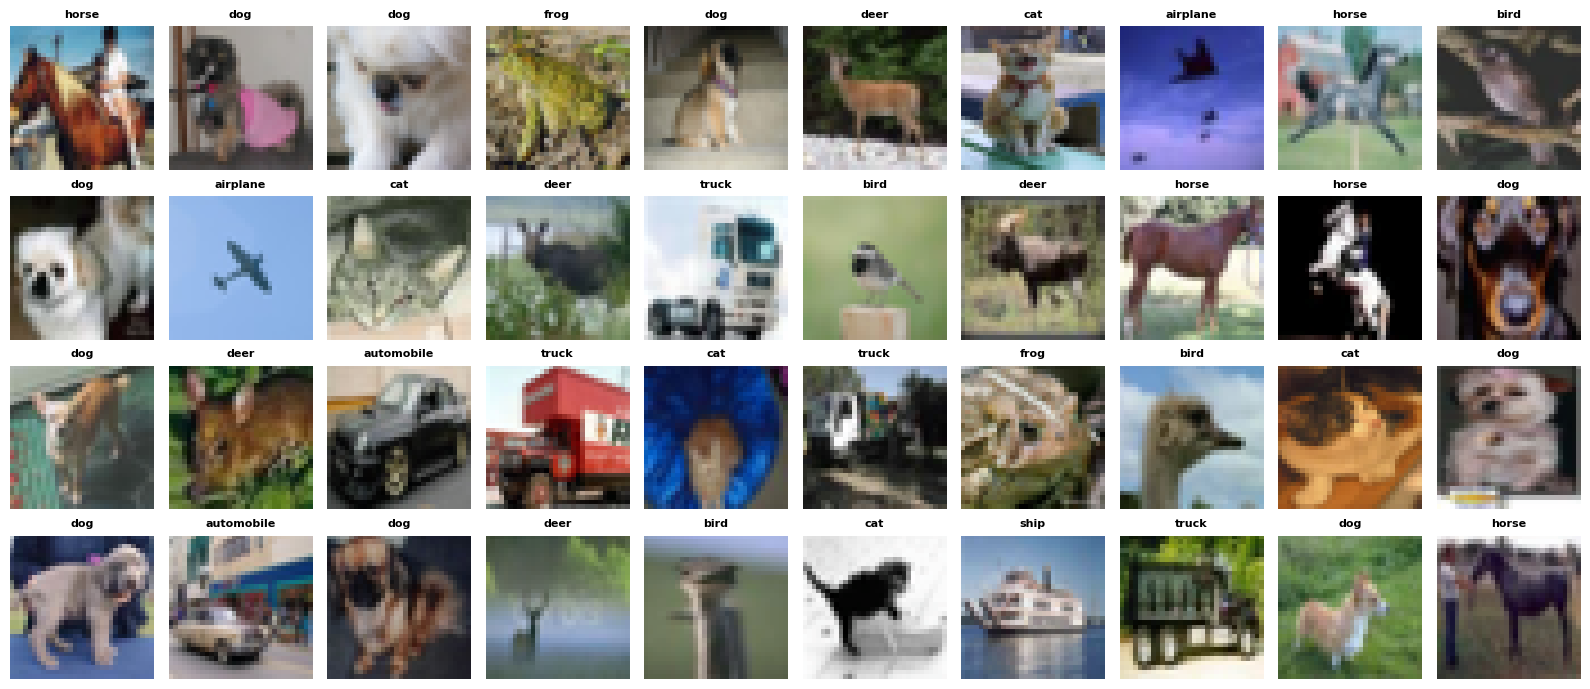

In [3]:
set_seed(0)
n_show = 40
idxs = np.random.choice(len(train_plain), n_show, replace=False)
imgs = [unnormalize(train_plain[i][0]) for i in idxs]
lbls = [CLASSES[train_plain[i][1]] for i in idxs]
show_image_grid(imgs, titles=lbls, nrows=4, figsize=(16, 7))

---
# Part 1 · Why non-linearity is unavoidable

Before touching CNNs, we build the core intuition with **synthetic 2-D data** where we can see the entire decision space at once.

A **linear model** (softmax regression) computes scores `z = Wx + b` — one score per class — and picks the largest. Geometrically, each class gets a *half-plane* separated by a straight line. That is fine when classes are **linearly separable** (Part 1.1), and hopeless when they are not (Part 1.2).

Two central facts will be demonstrated visually:
1. **Stacking linear layers without activations changes nothing** — the composition of linear maps is still a single linear map (Part 1.3).
2. **Inserting a non-linear activation between layers** lets a network bend its decision boundaries into arbitrary curves, wrapping around each class (Part 1.4). In 3-D you will see the *probability landscape* rise into peaks over each class region.


### 1.1 · When a single line *is* enough
We create two Gaussian blobs that are **linearly separable** and fit a logistic-regression classifier. The decision boundary (black line) splits the plane perfectly — accuracy ≈ 100%. For data like this, no depth and no activation function is needed; one linear layer suffices.


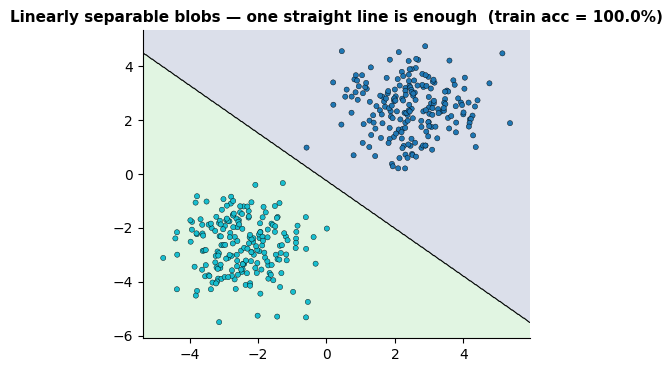

In [4]:
from sklearn.linear_model import LogisticRegression

class _FuncClf:
    # adapter: lets plot_decision accept a plain predict_proba function (torch models)
    def __init__(self, f): self.f = f
    def predict_proba(self, X): return self.f(X)

def plot_decision(clf, X, y, ax=None, title="", h=0.02, proba=True, class_names=None):
    # 2-D decision regions of a sklearn-style classifier with predict_proba
    if callable(clf) and not hasattr(clf, "predict_proba"):
        clf = _FuncClf(clf)
    x_min, x_max = X[:, 0].min() - .6, X[:, 0].max() + .6
    y_min, y_max = X[:, 1].min() - .6, X[:, 1].max() + .6
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict_proba(grid) if proba else None
    zz = Z.argmax(1).reshape(xx.shape)
    if ax is None: _, ax = plt.subplots(figsize=(5, 4))
    ax.contourf(xx, yy, zz, alpha=0.18, levels=np.arange(-0.5, zz.max() + 1.5), cmap="viridis")
    ax.contour(xx, yy, zz, colors="k", linewidths=0.8, levels=np.arange(-0.5, zz.max() + 1))
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=14, edgecolor="k", linewidth=0.3)
    if hasattr(clf, "predict_proba"):
        acc = (clf.predict_proba(X).argmax(1) == y).mean()
    elif hasattr(clf, "predict"):
        acc = (clf.predict(X) == y).mean()
    else:
        acc = float("nan")
    ax.set_title(f"{title}  (train acc = {acc:.1%})")
    if class_names:
        ax.legend(handles=sc.legend_elements()[0],
                  labels=list(class_names), frameon=False, fontsize=8)
    return ax

# linearly separable blobs
rng = np.random.RandomState(7)
Xa = np.r_[rng.randn(200, 2) + [2.5, 2.5], rng.randn(200, 2) + [-2.5, -2.5]]
ya = np.array([0] * 200 + [1] * 200)
lin1 = LogisticRegression().fit(Xa, ya)

plot_decision(lin1, Xa, ya, title="Linearly separable blobs — one straight line is enough")
plt.show()

### 1.2 · When one line is *not* enough: a 3-class spiral
Real data — including CIFAR-10 — is **not linearly separable**. We simulate that with three intertwined spirals. A single straight line cannot wrap around a spiral arm, so a linear softmax classifier is forced to chop the plane into three crude half-planes, misclassifying a large fraction of points.

The 3-D panels rotate this 2-D picture: the **height is the predicted probability** of each class over the plane. A linear model produces three *tilted planes* — probabilities rise linearly in one direction. No matter how you tilt three planes, you cannot carve out a spiral.


Spiral dataset: (900, 2) | classes: [0 1 2]


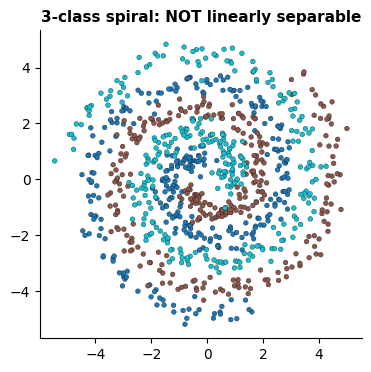

In [5]:
def make_spiral(n_per_class=300, n_classes=3, noise=0.05, turns=1.8, r_max=5.0, seed=11):
    # Three intertwined spirals — a classic non-linearly-separable problem
    rs = np.random.RandomState(seed)
    X, y = [], []
    for c in range(n_classes):
        t = np.linspace(0.15, 1.0, n_per_class)                # normalized radius
        r = t * r_max
        theta = t * turns * 2 * np.pi + c * 2 * np.pi / n_classes
        X.append(np.c_[r * np.cos(theta), r * np.sin(theta)]
                 + noise * r_max * rs.randn(n_per_class, 2))
        y.append(np.full(n_per_class, c))
    return np.vstack(X).astype(np.float32), np.concatenate(y)

Xs, ys = make_spiral()
print("Spiral dataset:", Xs.shape, "| classes:", np.unique(ys))

_, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap="tab10", s=12, edgecolor="k", linewidth=0.2)
ax.set_title("3-class spiral: NOT linearly separable"); ax.set_aspect("equal")
plt.show()

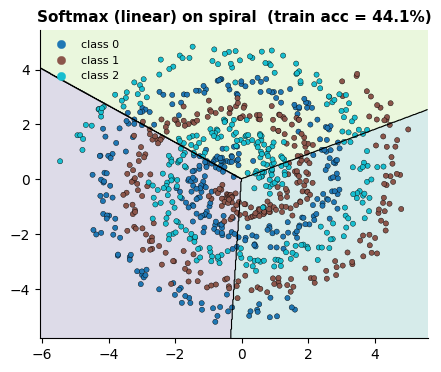

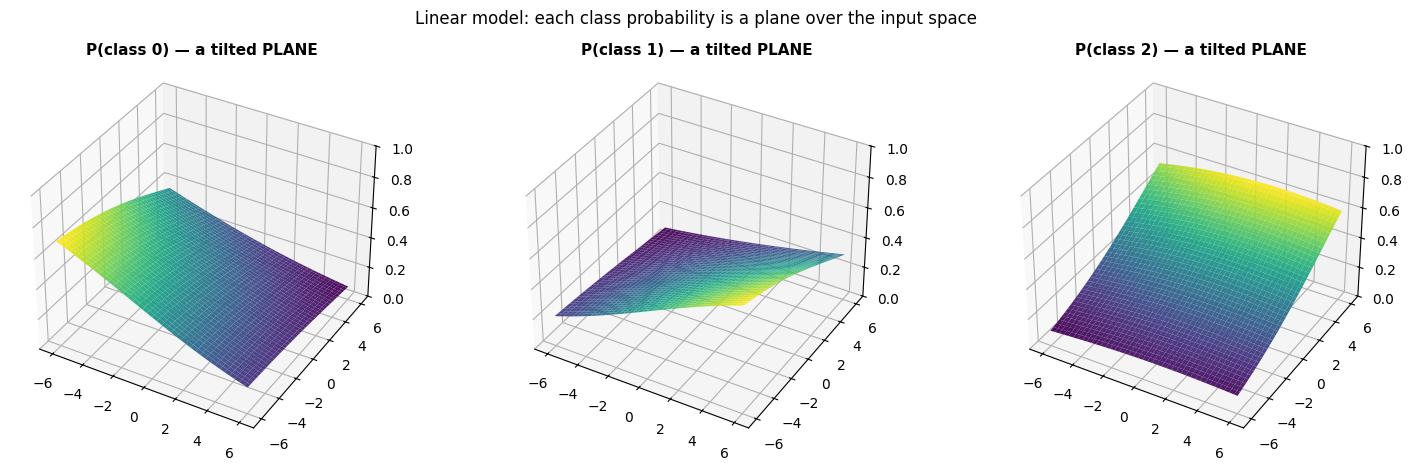

In [6]:
# linear softmax classifier on the spiral
lin_spi = LogisticRegression(max_iter=2000, C=10.0).fit(Xs, ys)
plot_decision(lin_spi, Xs, ys, title="Softmax (linear) on spiral", class_names=["class 0", "class 1", "class 2"])
plt.show()

# ---- 3-D probability landscape of the LINEAR model -------------------------
def proba_surface(clf_or_func, lim=6.0, n=120):
    # Returns xx, yy, P where P[:, :, c] = P(class c) on the grid
    xs = np.linspace(-lim, lim, n); ys = np.linspace(-lim, lim, n)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.c_[xx.ravel(), yy.ravel()]
    P = clf_or_func(grid).reshape(n, n, -1)
    return xx, yy, P

xx, yy, P = proba_surface(lin_spi.predict_proba)

fig = plt.figure(figsize=(15, 4.6))
for c in range(3):
    ax = fig.add_subplot(1, 3, c + 1, projection="3d")
    ax.plot_surface(xx, yy, P[:, :, c], cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)
    ax.set_zlim(0, 1); ax.set_title(f"P(class {c}) — a tilted PLANE")
    ax.view_init(elev=35, azim=-60)
fig.suptitle("Linear model: each class probability is a plane over the input space")
plt.tight_layout(); plt.show()

**Reading the 3-D figure.** Each surface is a probability *sheet* hovering over the 2-D input plane. For the linear model the sheets are flat tilted planes — their intersection lines are the straight decision boundaries. Where two sheets cross, the model switches classes. Because planes cannot curl, huge regions of the spiral are assigned to the wrong class.

**Question to keep in mind:** what would the surfaces look like if the model could *bend* them? (Answer in 1.4 — and in 3-D via the interactive Plotly figure.)


### 1.3 · Stacking linear layers without activations = still linear
A tempting idea: *if one linear layer is too weak, just stack several!* Let's test it. We train a torch network of **four `nn.Linear` layers with no activation in between** on the spiral.

Mathematically this cannot work: for consecutive linear layers,
$$h_2 = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)\,x + (W_2 b_1 + b_2),$$
so the whole stack collapses algebraically into a **single** affine map. The decision boundaries below are still straight lines — the extra layers bought us nothing except more parameters. **This is the entire reason activation functions exist.**


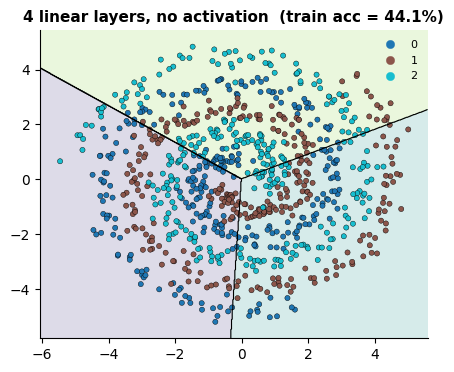

Effective weight matrix (product W3·W2·W1·W0) — the whole stack is ONE linear map:
[[-0.14 -0.11]
 [ 0.08 -0.13]
 [-0.02  0.08]]


In [7]:
set_seed(0)
# 4 linear layers, NO activation between them
linear_stack = nn.Sequential(
    nn.Linear(2, 16), nn.Linear(16, 16), nn.Linear(16, 16), nn.Linear(16, 3)
)

def train_torch_clf(model, X, y, epochs=800, lr=5e-3, wd=0.0):
    Xb = torch.tensor(X); yb = torch.tensor(y).long()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.CrossEntropyLoss()
    for ep in range(epochs):
        opt.zero_grad(); loss = lossf(model(Xb), yb); loss.backward(); opt.step()
    return model

linear_stack = train_torch_clf(linear_stack, Xs, ys)

def torch_proba_func(model):
    model.eval()
    def f(grid):
        with torch.no_grad():
            return F.softmax(model(torch.tensor(grid, dtype=torch.float32)), dim=1).numpy()
    return f

plot_decision(torch_proba_func(linear_stack), Xs, ys,
              title="4 linear layers, no activation", class_names=["0", "1", "2"])
plt.show()

with torch.no_grad():
    W_eff = linear_stack[3].weight @ linear_stack[2].weight @ linear_stack[1].weight @ linear_stack[0].weight
print("Effective weight matrix (product W3·W2·W1·W0) — the whole stack is ONE linear map:")
print(W_eff.numpy().round(2))

### 1.4 · Insert a non-linearity → boundaries can bend
Same spiral, same depth (4 layers), but now a **ReLU activation after every hidden layer**. The network finally wraps regions around each spiral arm. Watch the probability surfaces in 3-D: instead of tilted planes we now have **peaks and valleys** — hills of probability growing over each class region, exactly the landscape a classifier needs.

We train three variants (ReLU / Tanh / Sigmoid) so you can already see that *different activations carve different boundary shapes* — a preview of Part 5.


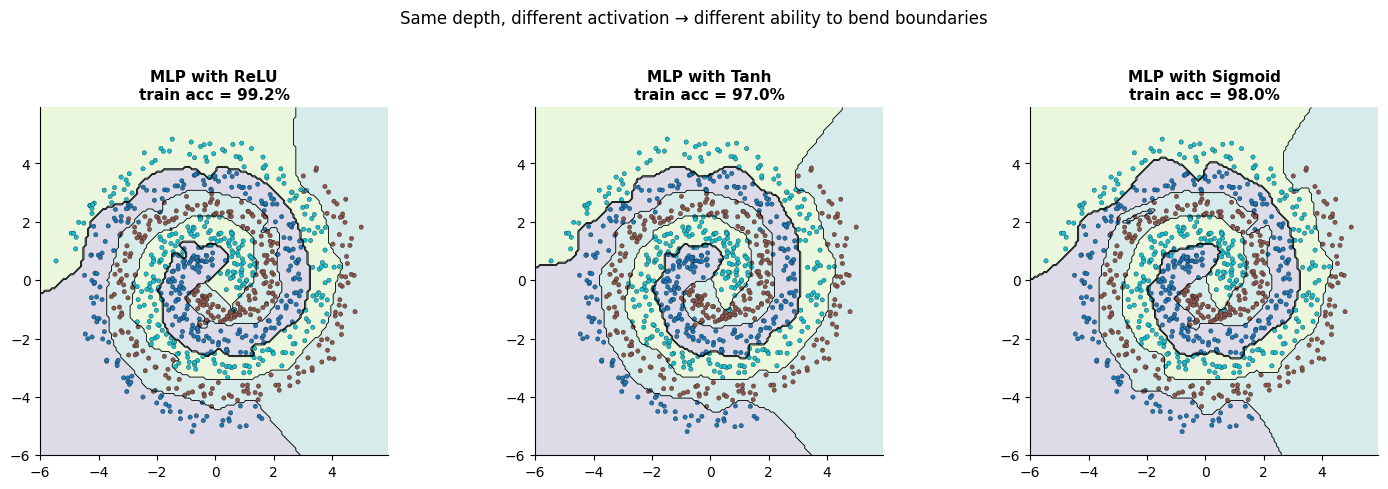

In [8]:
def build_mlp(hidden=64, layers=4, out=3, act=nn.ReLU):
    layers_list, prev = [], 2
    for _ in range(layers):
        layers_list += [nn.Linear(prev, hidden), act()]; prev = hidden
    layers_list += [nn.Linear(prev, out)]
    return nn.Sequential(*layers_list)

def torch_boundary(ax, model, X, y, title, lim=6.0, h=0.08):
    xs = np.arange(-lim, lim, h); xx, yy = np.meshgrid(xs, xs)
    f = torch_proba_func(model)
    zz = f(np.c_[xx.ravel(), yy.ravel()]).argmax(1).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.18, levels=np.arange(-0.5, zz.max() + 1.5), cmap="viridis")
    ax.contour(xx, yy, zz, colors="k", linewidths=0.6, levels=np.arange(-0.5, zz.max() + 1))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=10, edgecolor="k", linewidth=0.2)
    acc = (f(X).argmax(1) == y).mean()
    ax.set_title(f"{title}\ntrain acc = {acc:.1%}"); ax.set_aspect("equal")

mlps = {}
for name, act in [("ReLU", nn.ReLU), ("Tanh", nn.Tanh), ("Sigmoid", nn.Sigmoid)]:
    set_seed(0)
    mlps[name] = train_torch_clf(build_mlp(act=act), Xs, ys, epochs=1200, lr=5e-3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, m) in zip(axes, mlps.items()):
    torch_boundary(ax, m, Xs, ys, f"MLP with {name}")
plt.suptitle("Same depth, different activation → different ability to bend boundaries", y=1.04)
plt.tight_layout(); plt.show()

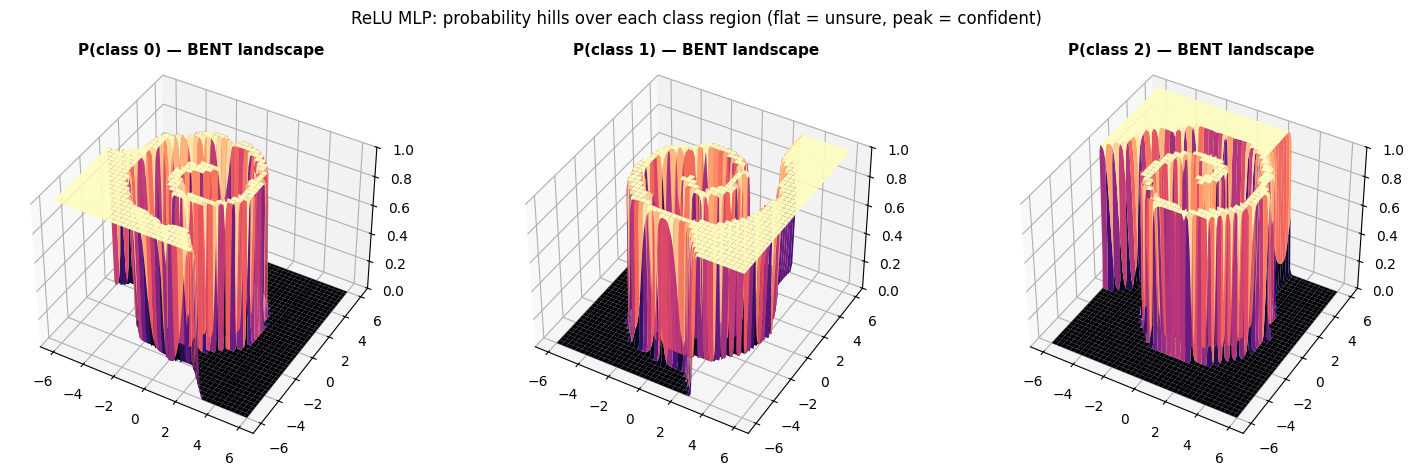

In [9]:
# ---- 3-D probability landscape of the ReLU MLP ------------------------------
f_mlp = torch_proba_func(mlps["ReLU"])
xx, yy, P = proba_surface(f_mlp)

fig = plt.figure(figsize=(15, 4.6))
for c in range(3):
    ax = fig.add_subplot(1, 3, c + 1, projection="3d")
    ax.plot_surface(xx, yy, P[:, :, c], cmap="magma", linewidth=0, antialiased=True)
    ax.set_zlim(0, 1); ax.set_title(f"P(class {c}) — BENT landscape")
    ax.view_init(elev=40, azim=-60)
fig.suptitle("ReLU MLP: probability hills over each class region (flat = unsure, peak = confident)")
plt.tight_layout(); plt.show()

if HAS_PLOTLY:
    colorscales = ["Viridis", "Cividis", "Plasma"]
    fig = go.Figure()
    xs1d = np.linspace(-6, 6, P.shape[0])
    for c in range(3):
        fig.add_trace(go.Surface(
            x=xs1d, y=xs1d, z=P[:, :, c], opacity=0.85, name=f"class {c}",
            colorscale=colorscales[c], showscale=False))
    fig.update_layout(title="Interactive: P(class) surfaces learned by the ReLU MLP — rotate me!",
                      scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="probability",
                                 zaxis=dict(range=[0, 1])), height=560, width=760)
    fig.show()

**Take-aways from Part 1**
- Linearly separable data → one linear layer is optimal (1.1).
- Real data is **not** linearly separable; a linear model's probability landscape is a set of planes and cannot wrap around structure (1.2).
- Depth without activation functions is a no-op: composition of affine maps is affine (1.3).
- A non-linear activation between layers lets the network build **piecewise-curved boundaries** and **bumpy probability landscapes** (1.4). Sigmoid's saturated plateaus make it fit the spiral noticeably worse than ReLU/Tanh — a first hint of the gradient problems we analyze in Part 2.

**How does this connect to images?** A 32×32 RGB image is a 3,072-dimensional input; classes like "cat" occupy wildly curved, intertwined regions of that space — *far* less separable than our 2-D spiral. CNNs solve it the same way: linear filters + non-linear activations, repeated layer after layer.


---
# Part 2 · Meet the activation functions
An activation function is a **fixed, non-linear, element-wise** function applied to a layer's output before it is passed on. Every property we need follows from those three words: *fixed* (no parameters to learn — with PReLU as the interesting exception), *non-linear* (it bends the space), *element-wise* (it acts on each scalar independently, so it never mixes pixels — the mixing is the linear part's job).

We will study seven functions. Formulas first:

| Function | Formula | Range |
|---|---|---|
| **ReLU** | $f(x)=\max(0,\,x)$ | $[0,\infty)$ |
| **Leaky ReLU** | $f(x)=x$ if $x>0$ else $0.1\,x$ | $(-\infty,\infty)$ |
| **PReLU** | like Leaky ReLU, but the negative slope $a$ is **learned** | $(-\infty,\infty)$ |
| **ELU** | $f(x)=x$ if $x>0$ else $\alpha\,(e^{x}-1)$, $\alpha=1$ | $(-\alpha,\infty)$ |
| **Sigmoid** | $f(x)=\dfrac{1}{1+e^{-x}}$ | $(0,1)$ |
| **Tanh** | $f(x)=\dfrac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$ | $(-1,1)$ |
| **GELU** | $f(x)=x\cdot\Phi(x)\approx 0.5\,x\,(1+\tanh[\sqrt{2/\pi}\,(x+0.0447\,x^3)])$ | $\approx(-0.17,\infty)$ |

Two questions to ask of every activation:
1. **What does it do to positive inputs?** (images produce many positive filter responses — bright edges on dark backgrounds)
2. **What does its *derivative* look like?** Backpropagation multiplies derivatives layer by layer; wherever the derivative is ≈ 0 for long stretches, gradients vanish and those layers stop learning.


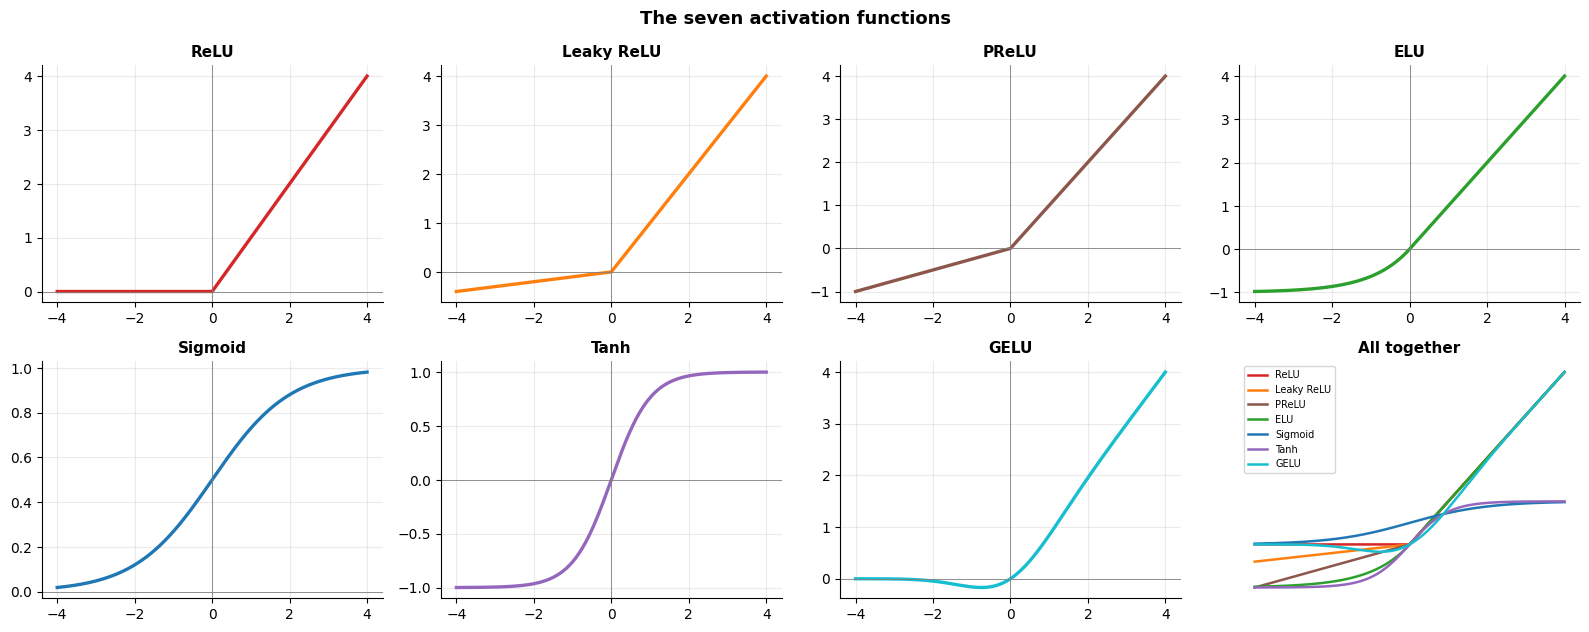

In [10]:
# ---- define the seven activations ------------------------------------------
import pandas as pd

def make_activation(name):
    # Factory: name -> fresh nn.Module (used to build every CNN in this notebook).
    table = {
        "relu":       lambda: nn.ReLU(),
        "leaky_relu": lambda: nn.LeakyReLU(negative_slope=0.1),
        "prelu":      lambda: nn.PReLU(),
        "elu":        lambda: nn.ELU(alpha=1.0),
        "sigmoid":    lambda: nn.Sigmoid(),
        "tanh":       lambda: nn.Tanh(),
        "gelu":       lambda: nn.GELU(),          # exact erf-based GELU
    }
    return table[name]()

ACTS  = ["relu", "leaky_relu", "prelu", "elu", "sigmoid", "tanh", "gelu"]
NAMES = {"relu": "ReLU", "leaky_relu": "Leaky ReLU", "prelu": "PReLU",
         "elu": "ELU", "sigmoid": "Sigmoid", "tanh": "Tanh", "gelu": "GELU"}
COLORS = {"relu": "#d62728", "leaky_relu": "#ff7f0e", "prelu": "#8c564b",
          "elu": "#2ca02c", "sigmoid": "#1f77b4", "tanh": "#9467bd", "gelu": "#17becf"}

# numerical derivatives via autograd
x_in = torch.linspace(-4, 4, 401, dtype=torch.float32)
vals, ders = {}, {}
for name in ACTS:
    x = x_in.clone().requires_grad_(True)
    y = make_activation(name)(x)
    y.sum().backward()
    vals[name] = y.detach().numpy()
    ders[name] = x.grad.numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
for ax, name in zip(axes.ravel(), ACTS):
    ax.plot(x_in, vals[name], color=COLORS[name], lw=2.4)
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
    ax.set_title(NAMES[name]); ax.grid(alpha=0.25)
axes.ravel()[-1].axis("off")
# overlay panel for direct comparison
ax = axes.ravel()[-1]
for name in ACTS:
    ax.plot(x_in, vals[name], color=COLORS[name], lw=1.8, label=NAMES[name])
ax.set_title("All together"); ax.legend(fontsize=7); ax.grid(alpha=0.25)
fig.suptitle("The seven activation functions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

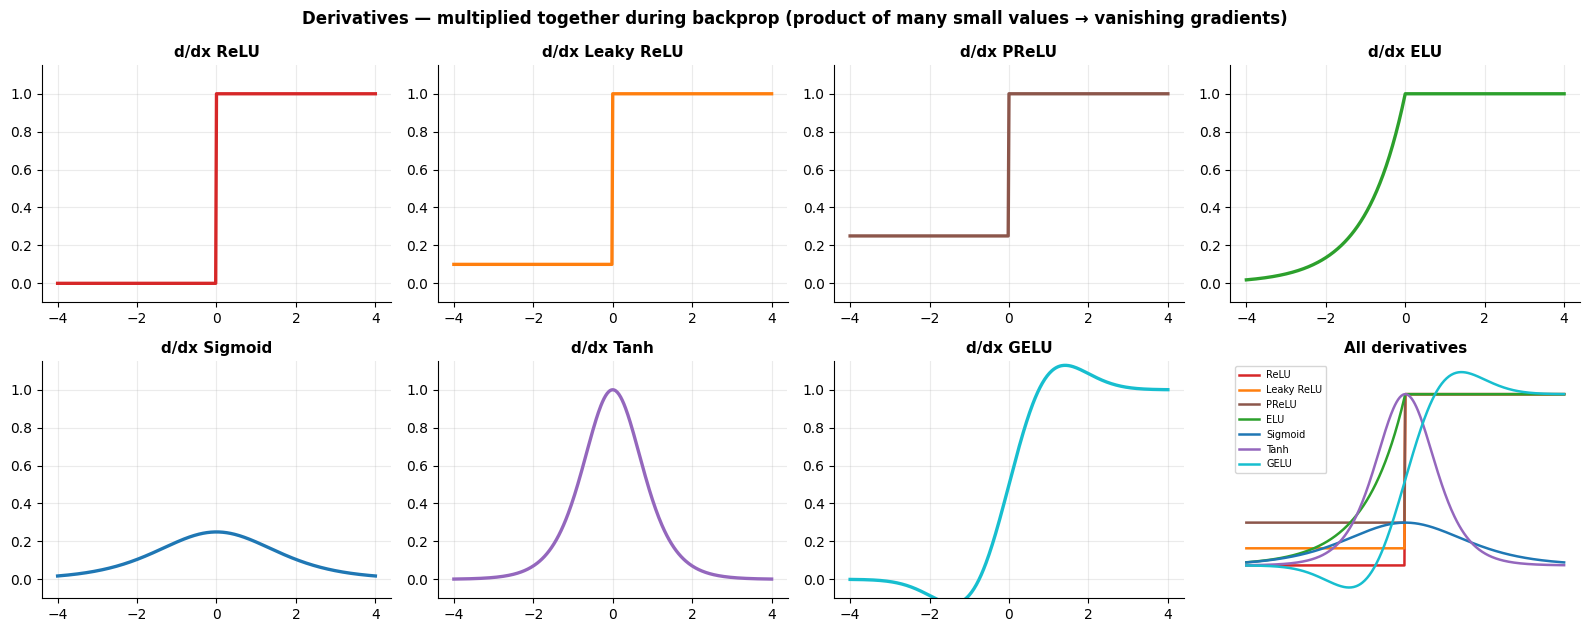

In [11]:
# ---- their derivatives: the backpropagation view ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
for ax, name in zip(axes.ravel(), ACTS):
    ax.plot(x_in, ders[name], color=COLORS[name], lw=2.4)
    ax.set_ylim(-0.1, 1.15)
    ax.set_title(f"d/dx {NAMES[name]}"); ax.grid(alpha=0.25)
axes.ravel()[-1].axis("off")
ax = axes.ravel()[-1]
for name in ACTS:
    ax.plot(x_in, ders[name], color=COLORS[name], lw=1.8, label=NAMES[name])
ax.set_title("All derivatives"); ax.legend(fontsize=7); ax.grid(alpha=0.25)
fig.suptitle("Derivatives — multiplied together during backprop (product of many small values → vanishing gradients)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

### Reading the curves
- **ReLU**: kink at 0, derivative is exactly 1 for $x>0$ — gradients pass through *undiminished* on the positive side. But for $x<0$ both output and derivative are exactly 0: a neuron stuck on the negative side receives **no gradient ever** ("dead ReLU").
- **Leaky ReLU / PReLU**: keep a small slope (0.1 / learned $a$) on the negative side so dead neurons can recover; output is no longer sparse.
- **ELU**: smoothly saturates toward $-\alpha$ for negative inputs — keeps some gradient, *pushes mean activation toward zero* (like BatchNorm's dream), and is smooth at the kink.
- **Sigmoid**: derivative $\sigma(1-\sigma)$ peaks at only **0.25**, and is ≈ 0 in both saturated tails. Stack a few sigmoid layers and the gradient product collapses — this is the historical villain of deep learning.
- **Tanh**: zero-centred (a big plus over sigmoid) but still saturating; derivative peaks at 1.0 yet vanishes beyond $|x|\gtrsim 3$.
- **GELU**: ReLU smoothed — a probabilistic blend ("stochastically" gated by the Gaussian CDF $\Phi$), non-monotonic with a shallow dip near $x\approx-1$; the default in transformers.

**Effect on a distribution.** The next cell pushes a standard-normal sample through each function. Watch ReLU create **sparsity** (~50% exact zeros) — this is why post-ReLU feature maps look "cut out" in Part 4 — and watch Sigmoid *compress everything* into $(0,1)$, squashing the signal dynamic range.


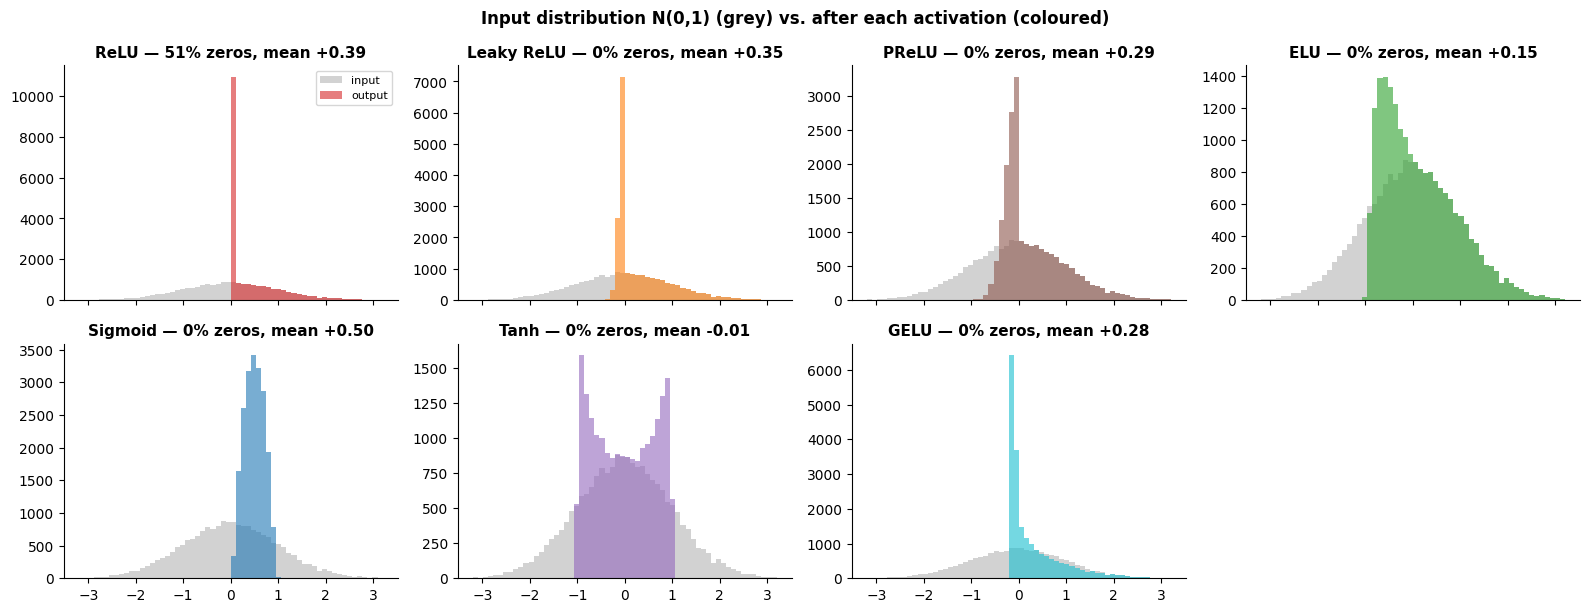

,function,range,monotonic,zero-centred,saturates?,"% zeros on N(0,1)"
0,ReLU,"[0, ∞)",True,False,no (x>0),50%
1,Leaky ReLU,"(-∞, ∞)",True,False,no,0%
2,PReLU,"(-∞, ∞)",True,False,no,0%
3,ELU,"(-1, ∞)",True,True,neg. side only,0%
4,Sigmoid,"(0, 1)",True,False,both sides,0%
5,Tanh,"(-1, 1)",True,True,both sides,0%
6,GELU,"≈(-0.17, ∞)",False,False,no,0%


In [12]:
set_seed(0)
xs = torch.randn(20000)
fig, axes = plt.subplots(2, 4, figsize=(16, 6.2), sharex=True)
bins = np.linspace(-3.2, 3.2, 61)
for ax, name in zip(axes.ravel(), ACTS):
    out = make_activation(name)(xs).detach().numpy()
    ax.hist(xs.numpy(),  bins=bins, alpha=0.35, label="input",  color="gray")
    ax.hist(out,         bins=bins, alpha=0.60, label="output", color=COLORS[name])
    frac0 = (np.abs(out) < 1e-6).mean()
    ax.set_title(f"{NAMES[name]} — {frac0:.0%} zeros, mean {out.mean():+.2f}")
    if name == ACTS[0]: ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Input distribution N(0,1) (grey) vs. after each activation (coloured)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "function": [NAMES[a] for a in ACTS],
    "range":    ["[0, ∞)", "(-∞, ∞)", "(-∞, ∞)", "(-1, ∞)", "(0, 1)", "(-1, 1)", "≈(-0.17, ∞)"],
    "monotonic": [True, True, True, True, True, True, False],
    "zero-centred": [False, False, False, True, False, True, False],
    "saturates?": ["no (x>0)", "no", "no", "neg. side only", "both sides", "both sides", "no"],
    "% zeros on N(0,1)": [f"{(np.abs(make_activation(a)(torch.randn(20000)).detach().numpy())<1e-6).mean():.0%}" for a in ACTS],
})
summary

**What to expect when we put these into the CNN (Part 5):**
- **ReLU / GELU / PReLU / ELU / Leaky ReLU** should train well: non-saturating on the positive side, decent gradient flow.
- **Sigmoid** should lag: saturation + non-zero-centred outputs make early layers learn slowly.
- **Tanh** sits in between: zero-centred but saturating.
- **ReLU** uniquely produces **sparse** feature maps — literally ~half the values zeroed — which we will *see* in the feature maps and *count* in the sparsity experiment.


---
# Part 3 · The CNN we will dissect
Before visualizing anything, we need a trained network. Our model is a compact 3-block CNN in the classic VGG style — small enough for CPU, yet every architectural idea of a real vision CNN is present:

| Block | Layers | Output shape | Role |
|---|---|---|---|
| Input | 32×32 RGB image | 3×32×32 | raw pixels |
| **Block 1** | Conv 3→32 (3×3) → BN → **Act** → MaxPool 2 | 32×16×16 | edges, colour blobs |
| **Block 2** | Conv 32→64 (3×3) → BN → **Act** → MaxPool 2 | 64×8×8 | textures, corners, motifs |
| **Block 3** | Conv 64→128 (3×3) → BN → **Act** → MaxPool 2 | 128×4×4 | object parts |
| **Head** | Flatten → FC 2048→256 → **Act** → Dropout → FC 256→10 | 10 logits | class scores |

Why convolutions? A 3×3 filter slides across the whole image with the **same weights** (weight sharing): it encodes a local pattern, and the feature map tells us *where* that pattern fires. Stacking convolutions grows the receptive field — layer 3 neurons see almost the entire image — while the **activation between blocks** is what lets each layer recombine its inputs non-linearly instead of just linearly re-mixing them.

**BatchNorm** sits *before* each activation: it standardizes each channel so that pre-activations stay in the responsive zone of the activation function (for ReLU: not permanently negative → not dead). **Dropout** in the head fights overfitting on our small training subset.


In [13]:
class ConvNet(nn.Module):
    # Compact VGG-style CNN; `activation` switches the non-linearity under study.
    def __init__(self, activation="relu", ch=(32, 64, 128), num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  ch[0], 3, padding=1)
        self.bn1   = nn.BatchNorm2d(ch[0]); self.act1 = make_activation(activation)
        self.conv2 = nn.Conv2d(ch[0], ch[1], 3, padding=1)
        self.bn2   = nn.BatchNorm2d(ch[1]); self.act2 = make_activation(activation)
        self.conv3 = nn.Conv2d(ch[1], ch[2], 3, padding=1)
        self.bn3   = nn.BatchNorm2d(ch[2]); self.act3 = make_activation(activation)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(ch[2] * 4 * 4, 256); self.act4 = make_activation(activation)
        self.drop  = nn.Dropout(0.25)
        self.fc2   = nn.Linear(256, num_classes)
        self._feat = None          # penultimate features (for PCA later)

    def forward(self, x):
        x = self.pool(self.act1(self.bn1(self.conv1(x))))
        x = self.pool(self.act2(self.bn2(self.conv2(x))))
        x = self.pool(self.act3(self.bn3(self.conv3(x))))
        x = x.flatten(1)
        x = self.act4(self.fc1(x)); self._feat = x
        return self.fc2(self.drop(x))

set_seed(SEED)
model = ConvNet("relu").to(DEVICE)

# per-layer shape & parameter audit via a probe forward pass
shapes, hooks = {}, []
def shape_hook(name):
    def fn(m, i, o): shapes[name] = tuple(o.shape)
    return fn
for n, m in model.named_children():
    if not n.startswith("_"): hooks.append(m.register_forward_hook(shape_hook(n)))
with torch.no_grad():
    model(torch.zeros(1, 3, 32, 32))
for h in hooks: h.remove()

audit = pd.DataFrame([
    {"layer": n, "module": type(dict(model.named_children())[n]).__name__,
     "output": str(shapes[n]),
     "params": sum(p.numel() for p in dict(model.named_children())[n].parameters())}
    for n, _ in model.named_children() if not n.startswith("_")])
print(audit.to_string(index=False))
print(f"\nTOTAL parameters: {sum(p.numel() for p in model.parameters()):,}")

layer      module          output  params
conv1      Conv2d (1, 32, 32, 32)     896
  bn1 BatchNorm2d (1, 32, 32, 32)      64
 act1        ReLU (1, 32, 32, 32)       0
conv2      Conv2d (1, 64, 16, 16)   18496
  bn2 BatchNorm2d (1, 64, 16, 16)     128
 act2        ReLU (1, 64, 16, 16)       0
conv3      Conv2d  (1, 128, 8, 8)   73856
  bn3 BatchNorm2d  (1, 128, 8, 8)     256
 act3        ReLU  (1, 128, 8, 8)       0
 pool   MaxPool2d  (1, 128, 4, 4)       0
  fc1      Linear        (1, 256)  524544
 act4        ReLU        (1, 256)       0
 drop     Dropout        (1, 256)       0
  fc2      Linear         (1, 10)    2570

TOTAL parameters: 620,810


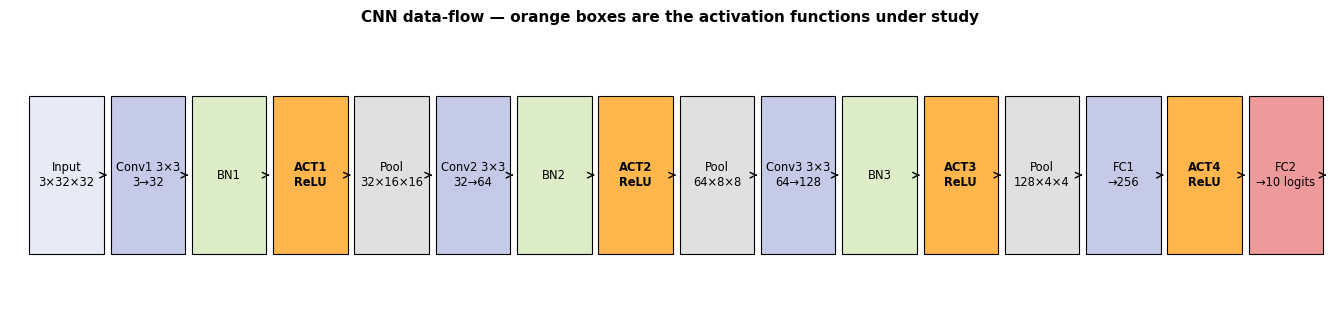

In [14]:
# ---- architecture block diagram ---------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 3.4))
blocks = [("Input\n3×32×32", "#e8eaf6"), ("Conv1 3×3\n3→32", "#c5cae9"),
          ("BN1", "#dcedc8"), ("**ACT1**\nReLU", "#ffb74d"), ("Pool\n32×16×16", "#e0e0e0"),
          ("Conv2 3×3\n32→64", "#c5cae9"), ("BN2", "#dcedc8"), ("**ACT2**\nReLU", "#ffb74d"),
          ("Pool\n64×8×8", "#e0e0e0"), ("Conv3 3×3\n64→128", "#c5cae9"),
          ("BN3", "#dcedc8"), ("**ACT3**\nReLU", "#ffb74d"), ("Pool\n128×4×4", "#e0e0e0"),
          ("FC1\n→256", "#c5cae9"), ("**ACT4**\nReLU", "#ffb74d"),
          ("FC2\n→10 logits", "#ef9a9a")]
x = 0.4
for label, color in blocks:
    ax.add_patch(plt.Rectangle((x, 0.25), 1.55, 0.6, facecolor=color, edgecolor="k", lw=0.8))
    label_plain = label.replace("**", "")
    ax.text(x + 0.775, 0.55, label_plain, ha="center", va="center", fontsize=8.3,
            fontweight="bold" if "ACT" in label else "normal")
    x += 1.55
    ax.annotate("", xy=(x + 0.12, 0.55), xytext=(x - 0.02, 0.55),
                arrowprops=dict(arrowstyle="->", lw=1.0))
    x += 0.14
ax.set_xlim(0, x); ax.set_ylim(0, 1.1); ax.axis("off")
ax.set_title("CNN data-flow — orange boxes are the activation functions under study")
plt.tight_layout(); plt.show()

### 3.1 · Training protocol
- **Optimizer**: Adam, learning rate $10^{-3}$ (robust default for small CNNs).
- **Loss**: cross-entropy over the 10 logits — note that the softmax that turns logits into probabilities is itself an activation function, applied only at read-out time.
- **Budget**: `CONFIG["main_epochs"]` = 8 epochs over the full 50,000-image training split (~10 minutes on a modern 2-core CPU; raise epochs or add augmentation on GPU for the last few accuracy points). **Checkpoints are cached** in `artifacts/`; delete the file to retrain live.
- Every activation-comparison model in Part 5 uses the *identical* protocol, seed, and data order — the **only** variable is the activation function.


In [15]:
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss = tot_correct = tot_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            tot_loss += criterion(out, yb).item() * len(xb)
            tot_correct += (out.argmax(1) == yb).sum().item(); tot_n += len(xb)
    return tot_loss / tot_n, tot_correct / tot_n

def train_model(model, tr_loader, te_loader, epochs, lr=CONFIG["lr"], tag=""):
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {k: [] for k in ["train_loss", "train_acc", "test_loss", "test_acc"]}
    for ep in range(1, epochs + 1):
        model.train(); t0 = time.time()
        run_loss = run_corr = run_n = 0
        for xb, yb in tr_loader:
            opt.zero_grad()
            out = model(xb); loss = criterion(out, yb)
            loss.backward(); opt.step()
            run_loss += loss.item() * len(xb)
            run_corr += (out.argmax(1) == yb).sum().item(); run_n += len(xb)
        te_loss, te_acc = evaluate(model, te_loader, criterion)
        hist["train_loss"].append(run_loss / run_n); hist["train_acc"].append(run_corr / run_n)
        hist["test_loss"].append(te_loss);           hist["test_acc"].append(te_acc)
        print(f"  [{tag}] epoch {ep:2d}/{epochs}  train_acc {hist['train_acc'][-1]:.3f}  "
              f"test_acc {te_acc:.3f}  ({time.time()-t0:.0f}s)")
    return hist

# ---- train (or load cached) the hero ReLU model -----------------------------
CACHE = os.path.join(ART, "hero_relu.pt")
train_loader = loader(train_main, shuffle=True)
if os.path.exists(CACHE):
    ck = torch.load(CACHE, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["state"]); hist = ck["hist"]
    print(f"Loaded cached hero model from {CACHE} (delete to retrain)")
else:
    set_seed(SEED)
    model = ConvNet("relu").to(DEVICE)
    print(f"Training hero ReLU CNN on {len(train_main)} images ...")
    hist = train_model(model, train_loader, test_loader,
                       epochs=CONFIG["main_epochs"], tag="ReLU")
    torch.save({"state": model.state_dict(), "hist": hist}, CACHE)
    print(f"Saved checkpoint -> {CACHE}")

Loaded cached hero model from artifacts/hero_relu.pt (delete to retrain)


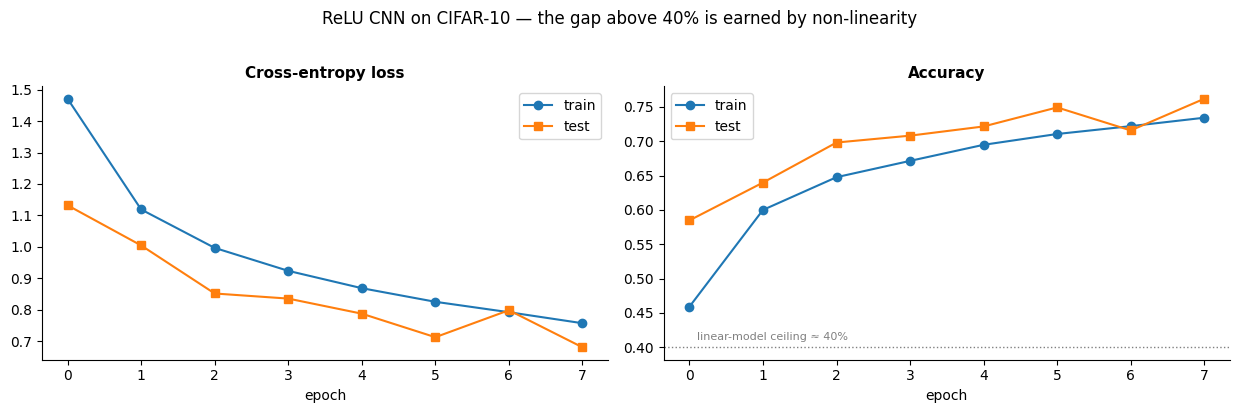

In [16]:
# ---- learning curves ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].plot(hist["train_loss"], "o-", label="train")
axes[0].plot(hist["test_loss"], "s-", label="test")
axes[0].set_xlabel("epoch"); axes[0].set_title("Cross-entropy loss"); axes[0].legend()
axes[1].plot(hist["train_acc"], "o-", label="train")
axes[1].plot(hist["test_acc"], "s-", label="test")
axes[1].set_xlabel("epoch"); axes[1].set_title("Accuracy")
axes[1].axhline(0.40, color="gray", ls=":", lw=1)
axes[1].text(0.1, 0.41, "linear-model ceiling ≈ 40%", fontsize=8, color="gray")
axes[1].legend()
fig.suptitle("ReLU CNN on CIFAR-10 — the gap above 40% is earned by non-linearity", y=1.02)
plt.tight_layout(); plt.show()

### 3.2 · Evaluation: where the model's decisions land
We run the trained model over the full 10,000-image test set and build the **confusion matrix** — rows are the true class, columns the predicted class. The diagonal carries correct decisions; off-diagonal cells reveal *systematic* confusions (cat↔dog, automobile↔truck …) that we will explain later with Grad-CAM: the model fires on features that two classes genuinely share (fur texture, wheel shape).


Hero ReLU CNN test accuracy: 76.17%  (7,617/10,000)


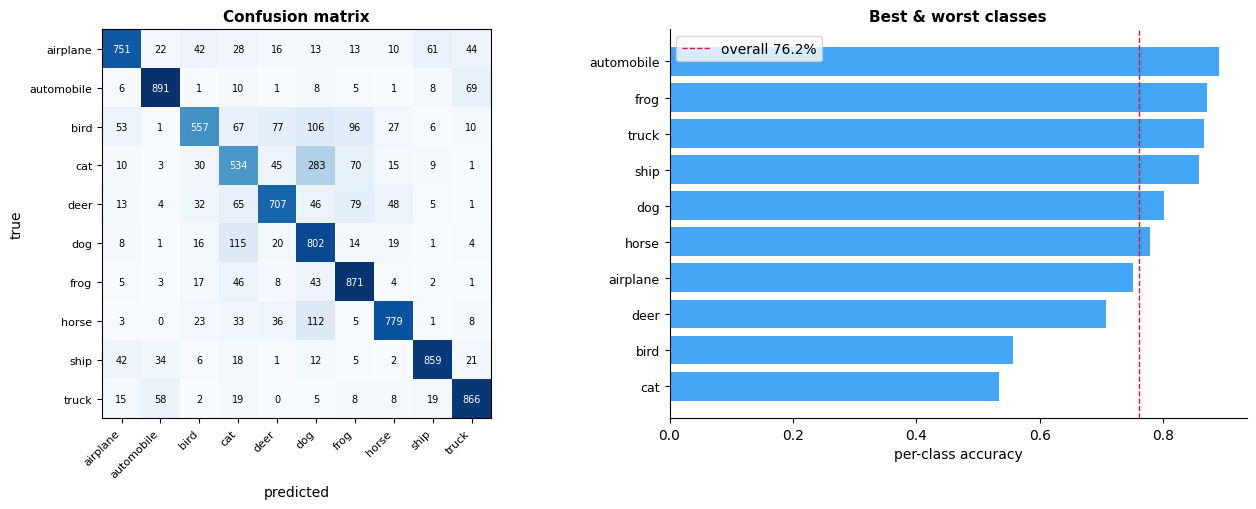

Most confused pairs: [('cat', 'dog', np.int64(283)), ('dog', 'cat', np.int64(115)), ('horse', 'dog', np.int64(112)), ('bird', 'dog', np.int64(106)), ('bird', 'frog', np.int64(96))]


In [17]:
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.append(model(xb).argmax(1)); all_true.append(yb)
all_pred = torch.cat(all_pred).numpy(); all_true = torch.cat(all_true).numpy()
test_acc = (all_pred == all_true).mean()
print(f"Hero ReLU CNN test accuracy: {test_acc:.2%}  ({(all_pred==all_true).sum():,}/{len(all_true):,})")

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_true, all_pred): cm[t, p] += 1

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2),
                         gridspec_kw={"width_ratios": [1.15, 1]})
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks(range(10), CLASSES, rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(10), CLASSES, fontsize=8)
for i in range(10):
    for j in range(10):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                     color="white" if cm[i, j] > cm.max()/2 else "black")
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title("Confusion matrix")
for s in axes[0].spines.values(): s.set_visible(True)

per_class = cm.diagonal() / cm.sum(1)
order = np.argsort(per_class)
axes[1].barh(range(10), per_class[order], color="#42a5f5")
axes[1].set_yticks(range(10), [CLASSES[i] for i in order], fontsize=9)
axes[1].axvline(test_acc, color="crimson", ls="--", lw=1, label=f"overall {test_acc:.1%}")
axes[1].set_xlabel("per-class accuracy"); axes[1].set_title("Best & worst classes")
axes[1].legend(); plt.tight_layout(); plt.show()

worst_pairs = [(CLASSES[i], CLASSES[j], cm[i, j])
               for i in range(10) for j in range(10) if i != j]
worst_pairs.sort(key=lambda t: -t[2])
print("Most confused pairs:", worst_pairs[:5])

Typical outcome: **~75–85% test accuracy** (subset + CPU budget), with cats, birds and deer hardest. Compare the ~40% ceiling of a linear model on the same input: everything above that line is due to *non-linear* processing. Keep the confusion matrix in mind — in Part 6 we will point Grad-CAM at exactly these classes and watch *which image regions* drive the (right and wrong) decisions.


---
# Part 4 · Inside the CNN: every filter, every feature map
We now open the trained network. Two objects matter:

- A **filter** (kernel) is the small weight tensor a convolution slides over the input — e.g. `conv1` has 32 filters of size 3×3×3. Early-layer filters are directly plottable as tiny RGB images.
- A **feature map** is the response of *one* filter across all spatial positions of *one* input image — a 32×32 (then 16×16, 8×8, 4×4) heatmap of "how much does this pattern fire *here*?"

To capture intermediate tensors we attach **forward hooks** — small callbacks that fire after a module runs and record its output. We register them on *every* stage of every block: `conv_i` (raw linear convolution output, full of negative values), `bn_i` (after BatchNorm — our "before activation" tensor), and `act_i` (after the ReLU — "after activation"). Comparing `bn_i` → `act_i` **isolates exactly what the activation function does**, because it is the only operation between them.


In [18]:
# ---- hook machinery + capture maps for 3 test images -------------------------
def find_test_image(label_idx, offset=0):
    ys = np.array(test_set.targets)
    return int(np.where(ys == label_idx)[0][offset])

# one example per interesting class: cat, dog, ship
img_ids = [find_test_image(3), find_test_image(5), find_test_image(8)]
viz_imgs  = torch.stack([test_set[i][0] for i in img_ids])
viz_labels = [CLASSES[test_set[i][1]] for i in img_ids]

captures = {}   # name -> tensor (n_imgs, C, H, W)
hook_handles = []
def make_hook(name):
    def fn(m, inp, out): captures[name] = out.detach()
    return fn

for name in ["conv1", "bn1", "act1", "conv2", "bn2", "act2", "conv3", "bn3", "act3"]:
    hook_handles.append(dict(model.named_children())[name].register_forward_hook(make_hook(name)))

model.eval()
with torch.no_grad():
    model(viz_imgs)
for h in hook_handles: h.remove()

print("Captured tensors (3 images each):")
for k in ["conv1", "bn1", "act1", "conv2", "bn2", "act2", "conv3", "bn3", "act3"]:
    print(f"  {k:6s} {tuple(captures[k].shape)}")

def top_channels(name, img_i, n=10):
    # channels with the strongest, most structured response (highest variance)
    t = captures[name][img_i].flatten(1)
    order = t.var(dim=1).argsort(descending=True)
    return order[:n].tolist()

CAT, DOG, SHIP = 0, 1, 2   # indices into our 3 captured images

Captured tensors (3 images each):
  conv1  (3, 32, 32, 32)
  bn1    (3, 32, 32, 32)
  act1   (3, 32, 32, 32)
  conv2  (3, 64, 16, 16)
  bn2    (3, 64, 16, 16)
  act2   (3, 64, 16, 16)
  conv3  (3, 128, 8, 8)
  bn3    (3, 128, 8, 8)
  act3   (3, 128, 8, 8)


### 4.1 · The first-layer filters — what the CNN learned to look for
`conv1` holds 32 learnable 3×3×3 filters. Because they act directly on RGB pixels we can render each one as a tiny colour patch (min-max normalized). The classic signature appears: **edge detectors** of various orientations (dark–light transitions), **colour-opponent blobs** (red-vs-green, blue-vs-yellow) and flat grey patches (roughly "brightness" detectors). Nobody programmed them — gradient descent discovered them because they are the features that best reduce classification loss.

The second panel pairs each of the 8 strongest filters with **its feature map on the cat image**: a filter that is dark-left/bright-right fires (bright values in the map) wherever a left-to-right luminance step occurs — cat ears, whisker boundaries, the horizon of the background.


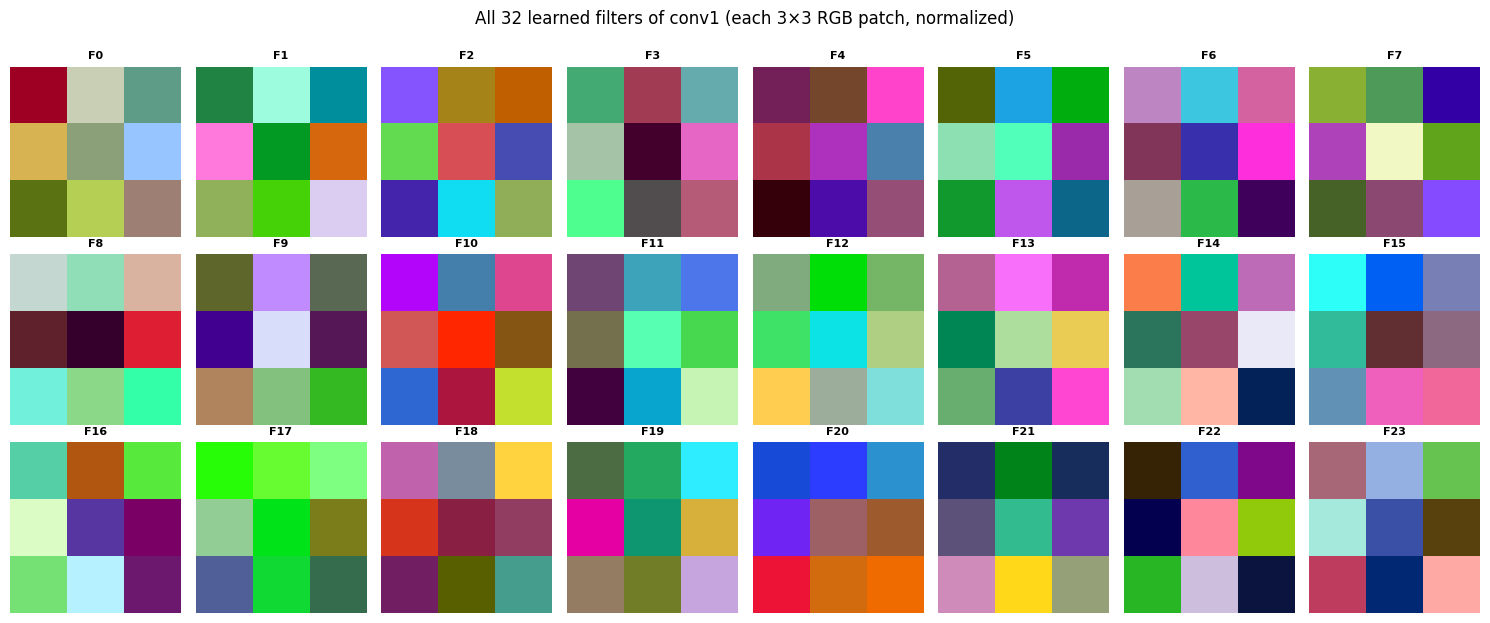

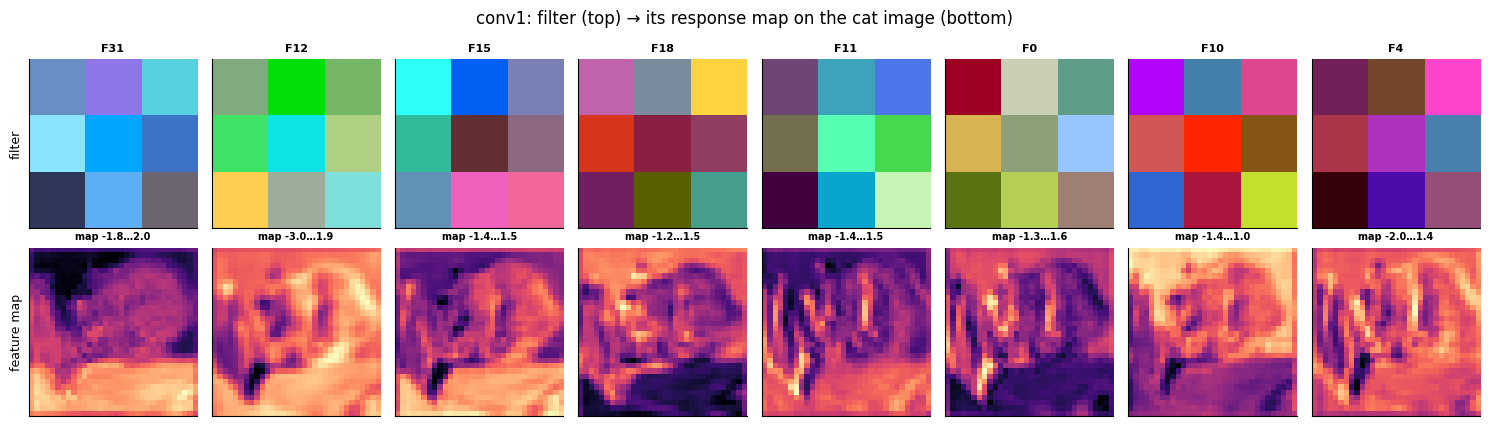

In [19]:
w1 = model.conv1.weight.detach().clone()      # (32, 3, 3, 3)
fmin, fmax = w1.amin(dim=(1, 2, 3), keepdim=True), w1.amax(dim=(1, 2, 3), keepdim=True)
filters01 = ((w1 - fmin) / (fmax - fmin + 1e-8)).numpy()

fig, axes = plt.subplots(3, 8, figsize=(15, 6.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters01[i].transpose(1, 2, 0), interpolation="nearest")
    ax.set_title(f"F{i}", fontsize=8); ax.axis("off")
fig.suptitle("All 32 learned filters of conv1 (each 3×3 RGB patch, normalized)", y=1.0)
plt.tight_layout(); plt.show()

# pair the 8 most responsive filters with their feature maps on the cat image
ch8 = top_channels("conv1", CAT, 8)
fig, axes = plt.subplots(2, 8, figsize=(15, 4.4))
for col, c in enumerate(ch8):
    axes[0, col].imshow(filters01[c].transpose(1, 2, 0), interpolation="nearest")
    axes[0, col].set_title(f"F{c}", fontsize=8)
    m = captures["conv1"][CAT, c].numpy()
    axes[1, col].imshow(m, cmap="magma")
    axes[1, col].set_title(f"map {m.min():.1f}…{m.max():.1f}", fontsize=7)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("filter", fontsize=9); axes[1, 0].set_ylabel("feature map", fontsize=9)
fig.suptitle("conv1: filter (top) → its response map on the cat image (bottom)")
plt.tight_layout(); plt.show()

### 4.2 · Block 1 — before vs. after the activation
Left of the activation, values live in $(-\infty, +\infty)$: a feature map is a *signed* signal where red (below) encodes "this pattern is anti-present". The activation (ReLU) applies one tiny program to every pixel: **negative → 0, positive → unchanged**.

Watch three things in the pair of rows below:
1. **Half of each map vanishes.** All red (negative) regions become black — ReLU carves the signed response into a *mask of where the pattern is present*.
2. **Positive regions are untouched** — ReLU is linear on $x>0$; it only *discards* information, it never rescales it.
3. The map becomes **sparse** (~40–60% exact zeros): zeros cost nothing to compute and, crucially, they **cannot pass gradients backwards**, so the network learns to be selective about what it keeps alive.


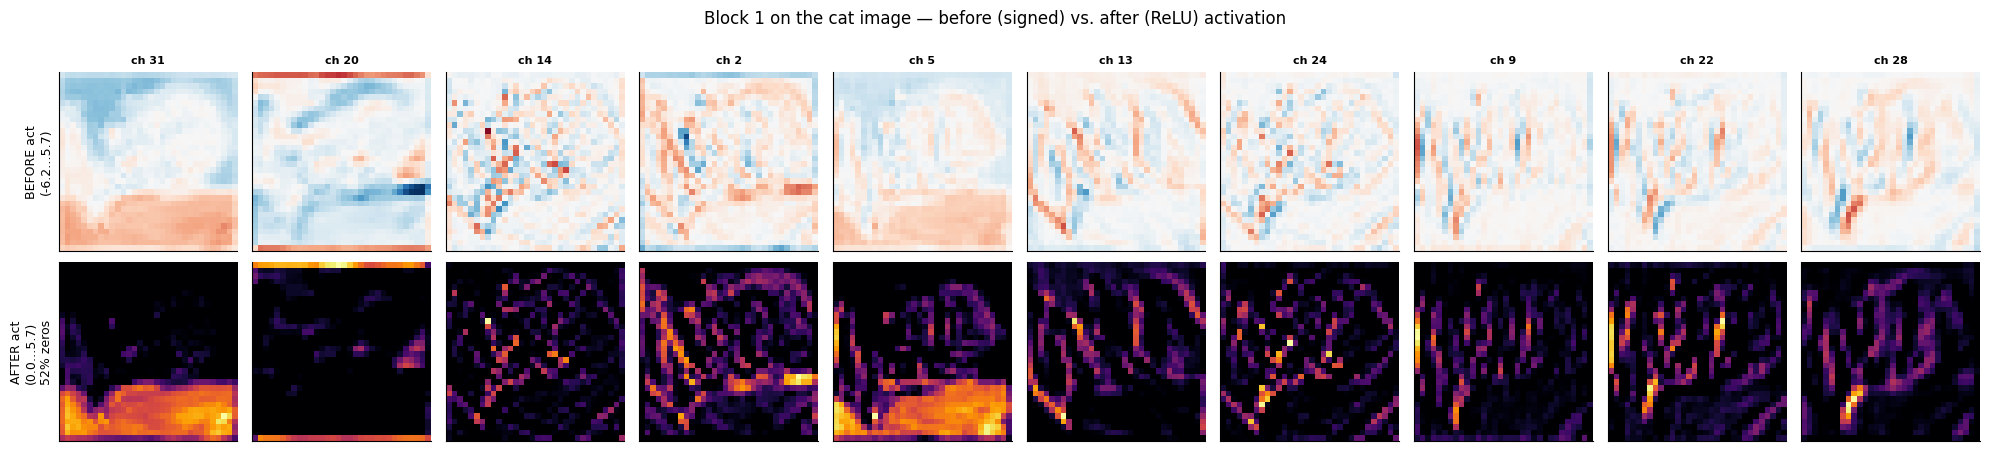

In [20]:
def before_after(layer, img_i, n_ch=10):
    pre  = captures[f"bn{layer}"][img_i]     # after BatchNorm, before activation
    post = captures[f"act{layer}"][img_i]    # after the activation function
    chans = top_channels(f"act{layer}", img_i, n_ch)
    # shared symmetric scale for the signed pre-activation row
    pre_v = max(abs(pre.min()), abs(pre.max()))
    fig, axes = plt.subplots(2, n_ch, figsize=(2.0 * n_ch, 4.6))
    for j, c in enumerate(chans):
        im0 = axes[0, j].imshow(pre[c].numpy(), cmap="RdBu_r", vmin=-pre_v, vmax=pre_v)
        axes[1, j].imshow(post[c].numpy(), cmap="inferno")
        axes[0, j].set_title(f"ch {c}", fontsize=8)
        for ax in (axes[0, j], axes[1, j]): ax.set_xticks([]); ax.set_yticks([])
    zr = (post.abs() < 1e-6).float().mean().item()
    axes[0, 0].set_ylabel(f"BEFORE act\n({pre.min().item():.1f}…{pre.max().item():.1f})", fontsize=9)
    axes[1, 0].set_ylabel(f"AFTER act\n({post.min().item():.1f}…{post.max().item():.1f})\n{zr:.0%} zeros", fontsize=9)
    fig.suptitle(f"Block {layer} on the {viz_labels[img_i].lower()} image — "
                 f"before (signed) vs. after (ReLU) activation", y=1.0)
    plt.tight_layout(); plt.show()
    return pre, post

pre1, post1 = before_after(1, CAT)

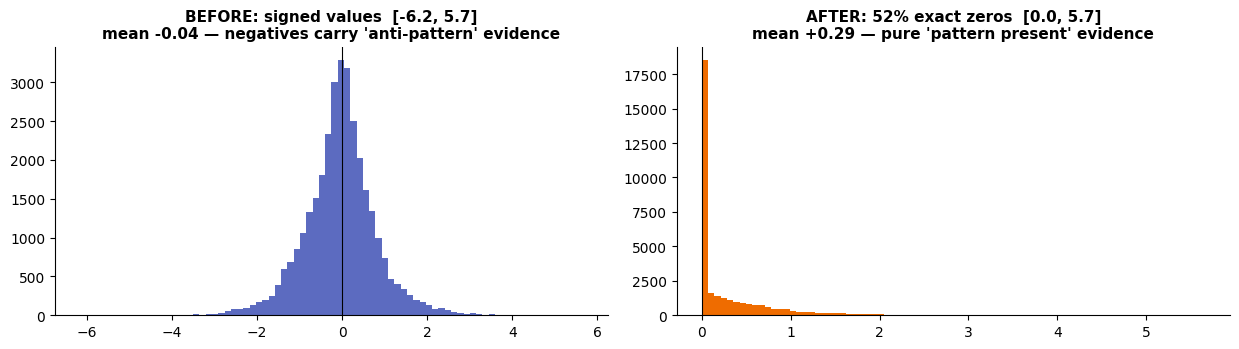

In [21]:
# value distributions before vs after ReLU, block 1 (cat image)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
axes[0].hist(pre1.flatten().numpy(), bins=80, color="#5c6bc0")
axes[0].set_title(f"BEFORE: signed values  [{pre1.min().item():.1f}, {pre1.max().item():.1f}]\n"
                  f"mean {pre1.mean().item():+.2f} — negatives carry 'anti-pattern' evidence")
axes[1].hist(post1.flatten().numpy(), bins=80, color="#ef6c00")
axes[1].set_title(f"AFTER: {((post1.abs()<1e-6).float().mean()):.0%} exact zeros  "
                  f"[{post1.min().item():.1f}, {post1.max().item():.1f}]\nmean {post1.mean().item():+.2f} — pure 'pattern present' evidence")
for ax in axes: ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

### 4.3 · Block 2 — patterns composed of patterns
`conv2` sees the *activated* maps of block 1, so its filters no longer detect edges — they detect **co-occurrences of edges**: corners, T-junctions, stripes, fur-like textures. Each of its 64 filters scans 32 input channels, so a single filter can fire on "a horizontal edge *and* a colour change". Downsampled to 16×16 then pooled to 8×8, each map cell now summarizes a larger patch of the original image (receptive field ≈ 10–14 px).

The same before/after story repeats one level up: signed texture evidence in, masked-out presence out. Note how the zero fraction tends to **rise** with depth (more and more channels are silent for any given image) — sparsity compounding through blocks.


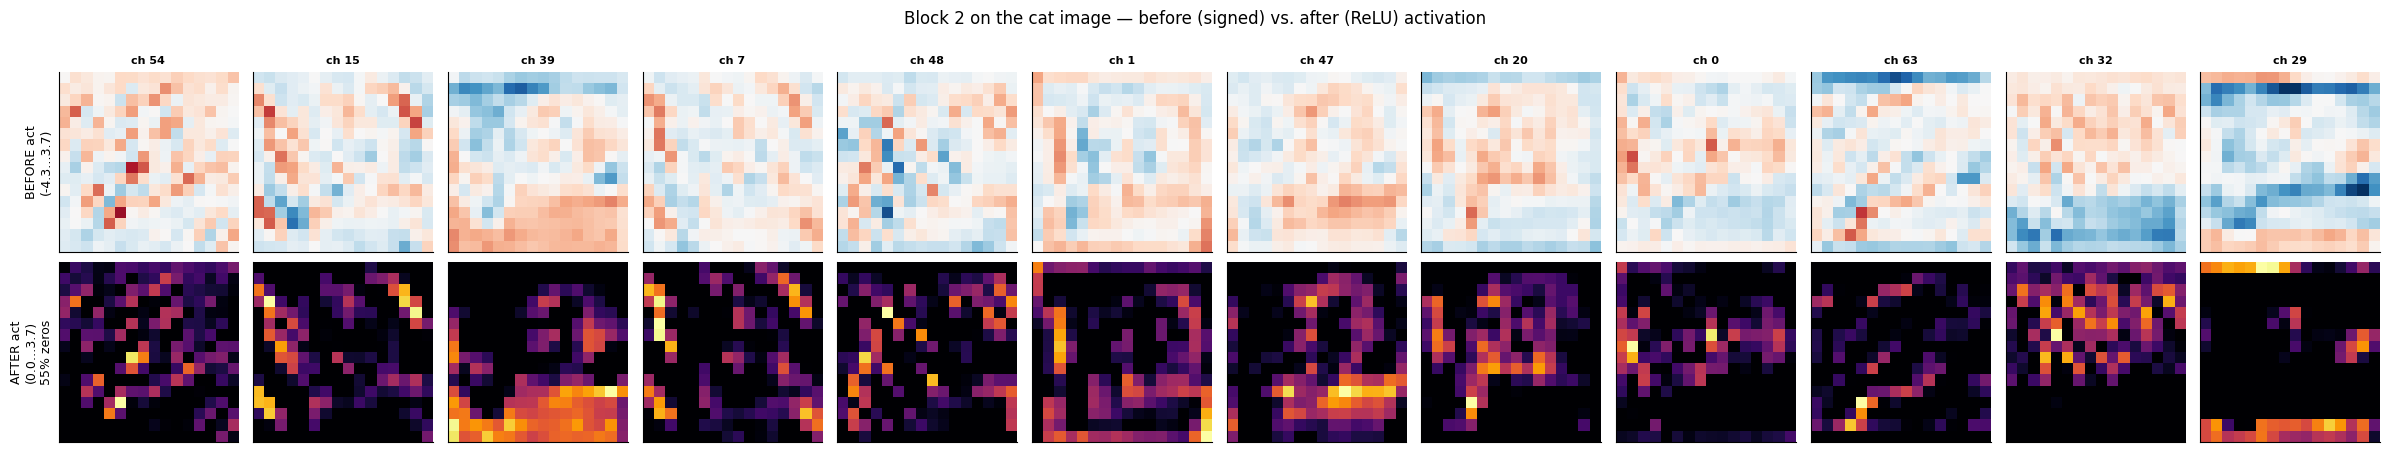

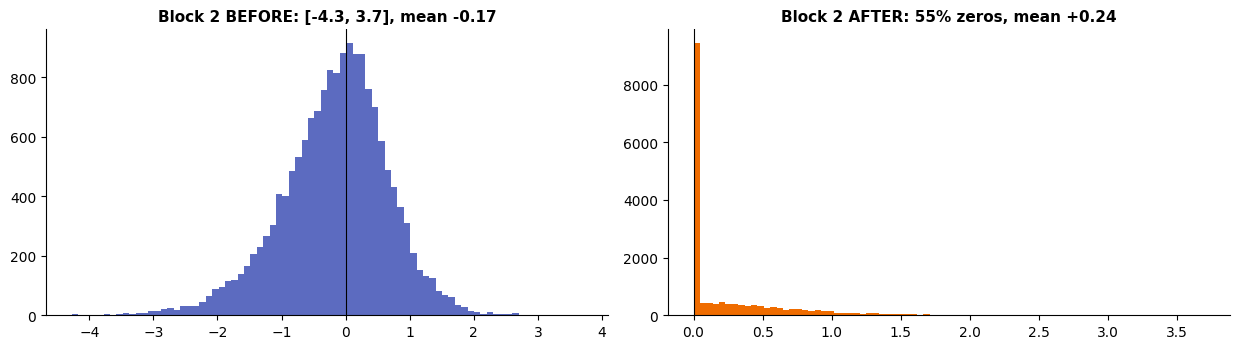

In [22]:
pre2, post2 = before_after(2, CAT, n_ch=12)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
axes[0].hist(pre2.flatten().numpy(), bins=80, color="#5c6bc0")
axes[0].set_title(f"Block 2 BEFORE: [{pre2.min().item():.1f}, {pre2.max().item():.1f}], mean {pre2.mean().item():+.2f}")
axes[1].hist(post2.flatten().numpy(), bins=80, color="#ef6c00")
axes[1].set_title(f"Block 2 AFTER: {((post2.abs()<1e-6).float().mean()):.0%} zeros, mean {post2.mean().item():+.2f}")
for ax in axes: ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

### 4.4 · Block 3 — object parts, almost concepts
By block 3 the receptive field is ~28–32 px — nearly the whole 32×32 image. Feature maps now light up on **object parts**: a cat's face+ears cluster, a ship's hull-and-water boundary, a dog's snout. Only 128 maps remain at 4×4 resolution: each cell is a coarse "this part is somewhere here" detector. After the final ReLU these maps feed the classifier head, which weights and sums them into class logits — literally *"evidence for cat = 3.2 × face-map + 1.1 × fur-texture-map − …"*.

This is where the activation function's fingerprints are most visible: the head reads **non-negative evidence**, because three ReLUs have removed every signed trace. Negative evidence lives only in the *absence* of activity.


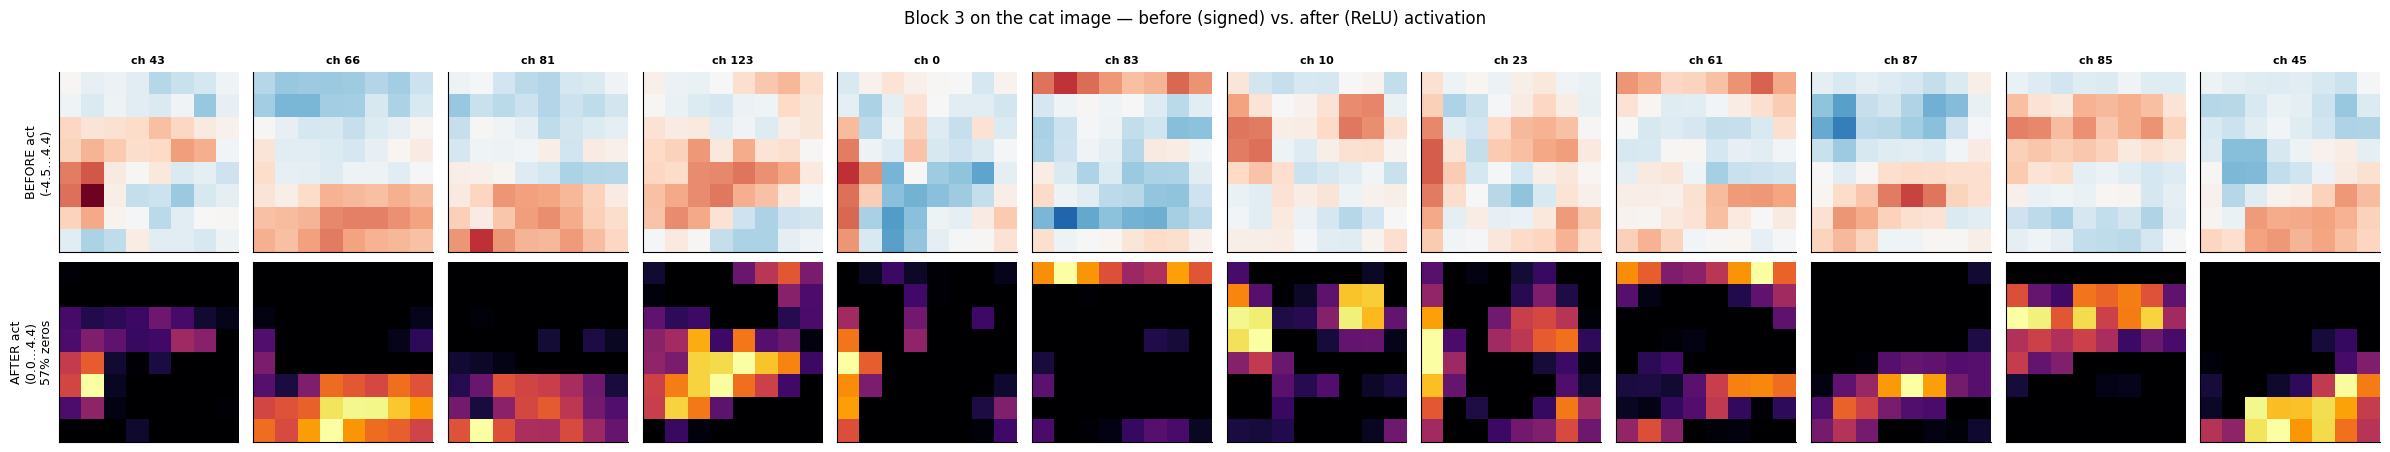

In [23]:
pre3, post3 = before_after(3, CAT, n_ch=12)

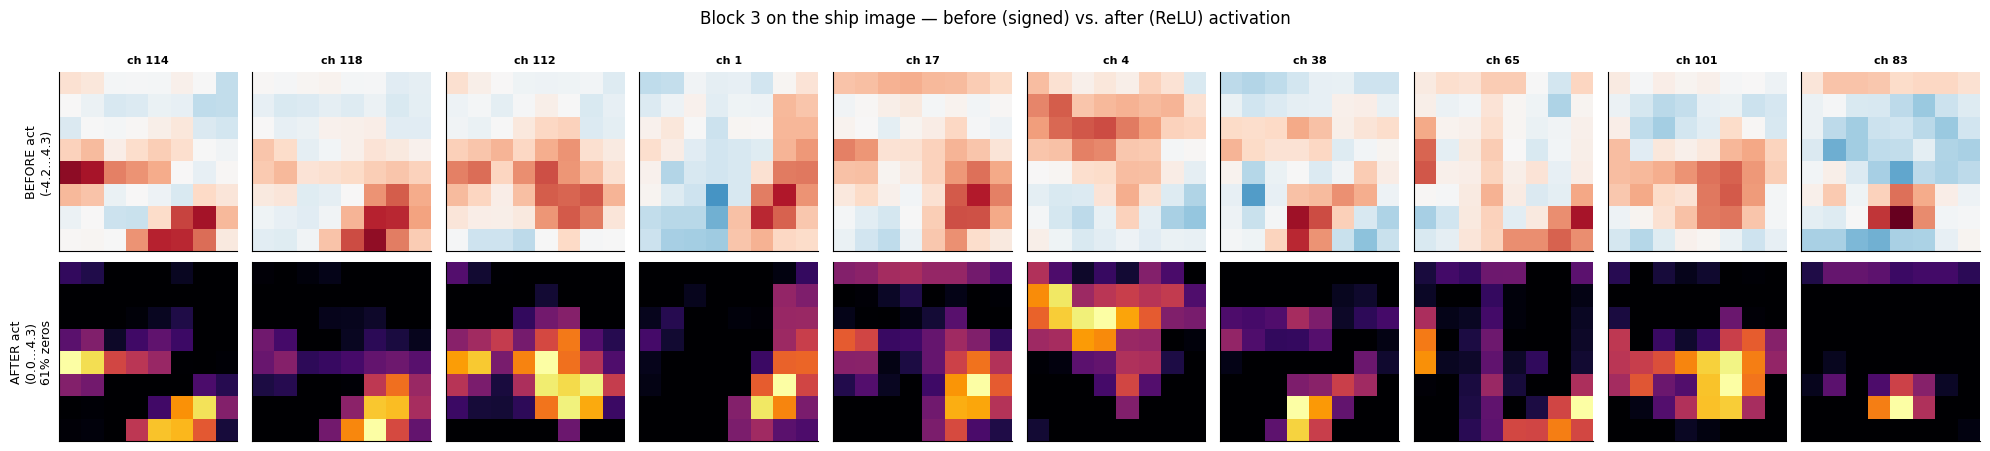

In [24]:
# same story for the ship image (block 3) — parts look different per class
_ = before_after(3, SHIP, n_ch=10)

### 4.5 · The whole journey: from pixels to decision-ready evidence
One figure, the full pipeline on the cat: input → 8 of the strongest maps after each activation. Resolution falls (32→16→8→4) while semantic content rises (pixels→edges→textures→parts). Every orange box in the architecture diagram is exactly one of these "masking" steps.


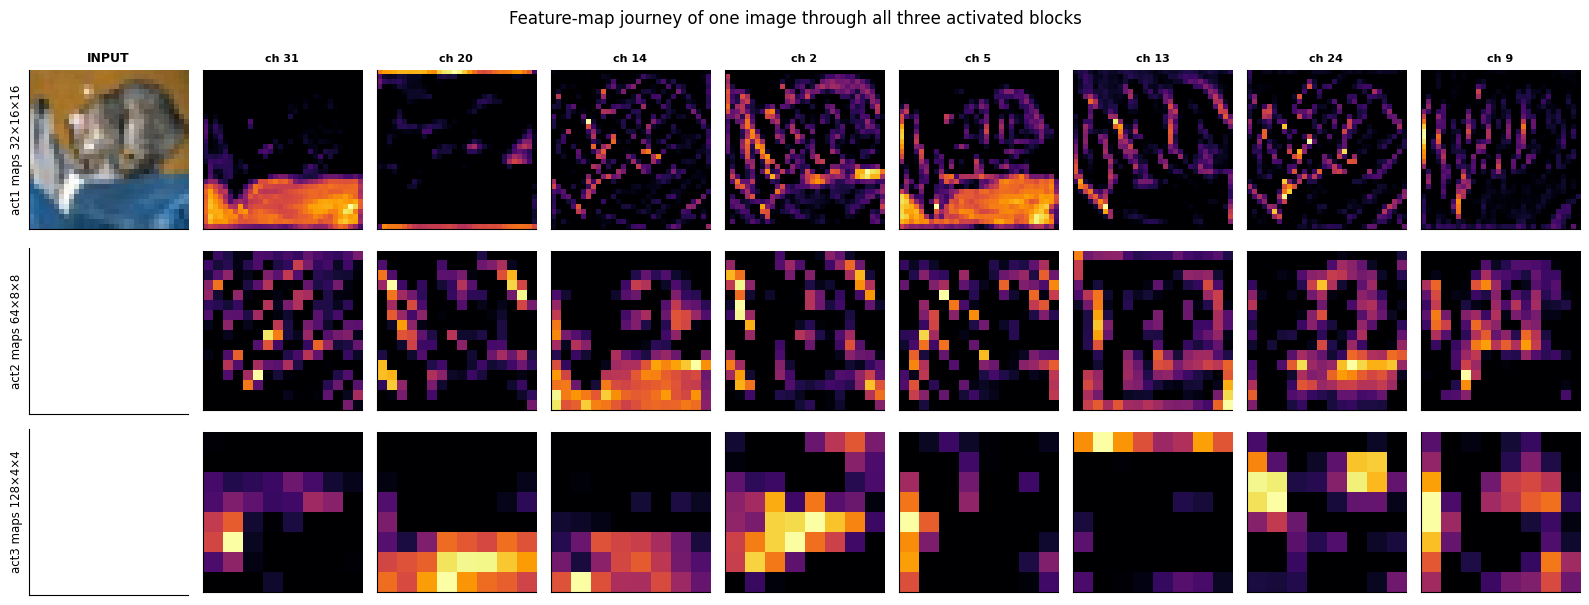

Zero-fraction after each activation (ReLU):
 image |   act1 |   act2 |   act3
   cat |  51.8% |  55.0% |  56.7%
   dog |  51.8% |  51.1% |  56.3%
  ship |  53.8% |  57.8% |  60.7%


In [25]:
fig, axes = plt.subplots(3, 9, figsize=(16, 6.0))
stage_cfg = [(1, "act1 maps 32×16×16"), (2, "act2 maps 64×8×8"), (3, "act3 maps 128×4×4")]
axes[0, 0].imshow(unnormalize(viz_imgs[CAT])); axes[0, 0].set_title("INPUT", fontsize=9)
for r, (layer, title) in enumerate(stage_cfg):
    chans = top_channels(f"act{layer}", CAT, 8)
    for j, c in enumerate(chans):
        m = captures[f"act{layer}"][CAT, c].numpy()
        axes[r, j + 1].imshow(m, cmap="inferno", interpolation="nearest")
        if r == 0: axes[r, j + 1].set_title(f"ch {c}", fontsize=8)
    axes[r, 0].set_ylabel(title, fontsize=8.5)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Feature-map journey of one image through all three activated blocks", y=1.0)
plt.tight_layout(); plt.show()

# sparsity stack-up across depth (cat, dog, ship)
print("Zero-fraction after each activation (ReLU):")
print(f"{'image':>6} | {'act1':>6} | {'act2':>6} | {'act3':>6}")
for i, lab in enumerate(viz_labels):
    zs = [(captures[f"act{l}"][i].abs() < 1e-6).float().mean().item() for l in (1, 2, 3)]
    print(f"{lab:>6} | {zs[0]:6.1%} | {zs[1]:6.1%} | {zs[2]:6.1%}")

**Recap of Part 4.** The activation function's role, seen in raw tensors:
- **Before**: signed, dense, Gaussian-ish values — both "pattern present" (positive) and "pattern absent/anti" (negative).
- **After** (ReLU): non-negative, sparse maps — clean *evidence masks* that the next layer can combine and the head can sum into logits.
- Without this masking step (Part 1.3!), three conv blocks would collapse into one big linear map — and linear maps, as the spiral showed, cannot carve a cat out of CIFAR-10.


---
# Part 5 · The controlled experiment: 7 CNNs, one variable
Now we put the gallery to work. We train **seven CNNs with identical architecture, identical data, identical seeds and identical optimizer** — the *only* difference is the activation function in every `act` slot (conv blocks and head).

Protocol per activation: the slim CNN (`ConvNet(ch=(16,32,64))`, ~157k parameters) trained for `CONFIG["cmp_epochs"]` epochs on the same fixed 8,000-image subset. Slimming the network keeps the 7-way comparison affordable on CPU while preserving the exact same structure of conv→BN→**act**→pool blocks we dissected in Part 4.

Checkpoints and histories are cached per activation in `artifacts/cmp_<name>.pt`, so the cell is instant on re-run. Expect the run to take a while the first time — this is the notebook's "expense account", buying us seven controlled experiments.


In [26]:
cmp_loader = DataLoader(train_cmp, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
cmp_results = {}

for name in ACTS:
    cache = os.path.join(ART, f"cmp_{name}.pt")
    if os.path.exists(cache):
        ck = torch.load(cache, map_location=DEVICE, weights_only=False)
        cmp_results[name] = {"hist": ck["hist"], "time": ck["time"]}
        print(f"{NAMES[name]:>11}: loaded cache (final test acc {ck['hist']['test_acc'][-1]:.3f})")
        continue
    set_seed(SEED)                       # same init & data order for everyone
    net = ConvNet(name, ch=(16, 32, 64)).to(DEVICE)
    t0 = time.time()
    h = train_model(net, cmp_loader, test_loader,
                    epochs=CONFIG["cmp_epochs"], tag=NAMES[name])
    dt = time.time() - t0
    torch.save({"state": net.state_dict(), "hist": h, "time": dt}, cache)
    cmp_results[name] = {"hist": h, "time": dt}

print("\nDone.")

       ReLU: loaded cache (final test acc 0.491)
 Leaky ReLU: loaded cache (final test acc 0.503)
      PReLU: loaded cache (final test acc 0.531)
        ELU: loaded cache (final test acc 0.531)
    Sigmoid: loaded cache (final test acc 0.307)
       Tanh: loaded cache (final test acc 0.504)
       GELU: loaded cache (final test acc 0.549)

Done.


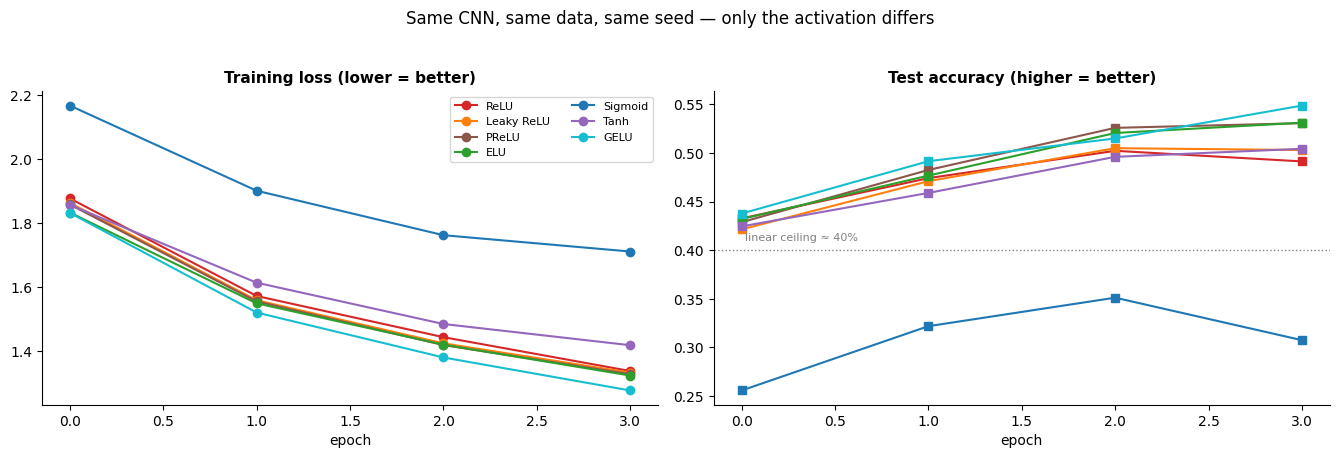

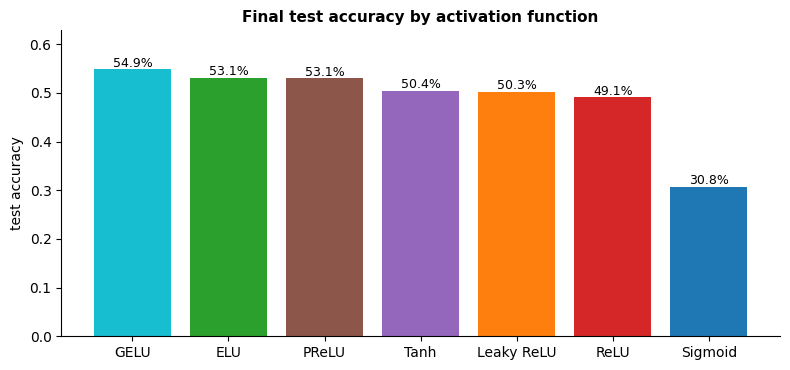

  activation | final test acc | last-epoch loss | train time
        GELU |          0.549 |           1.276 |       29s
         ELU |          0.531 |           1.323 |       29s
       PReLU |          0.531 |           1.328 |       29s
        Tanh |          0.504 |           1.418 |       27s
  Leaky ReLU |          0.503 |           1.332 |       27s
        ReLU |          0.491 |           1.337 |       26s
     Sigmoid |          0.307 |           1.711 |       27s


In [27]:
# ---- learning curves: loss & accuracy for all seven --------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for name in ACTS:
    h = cmp_results[name]["hist"]
    axes[0].plot(h["train_loss"], "o-", color=COLORS[name], label=NAMES[name])
    axes[1].plot(h["test_acc"], "s-", color=COLORS[name])
axes[0].set_title("Training loss (lower = better)"); axes[0].set_xlabel("epoch")
axes[1].set_title("Test accuracy (higher = better)"); axes[1].set_xlabel("epoch")
axes[1].axhline(0.40, color="gray", ls=":", lw=1)
axes[1].text(0.02, 0.41, "linear ceiling ≈ 40%", fontsize=8, color="gray")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Same CNN, same data, same seed — only the activation differs", y=1.03)
plt.tight_layout(); plt.show()

finals = {NAMES[n]: cmp_results[n]["hist"]["test_acc"][-1] for n in ACTS}
order = sorted(finals, key=finals.get, reverse=True)
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(order, [finals[k] for k in order],
              color=[COLORS[k.lower().replace(' ', '_')] for k in order])
for b, k in zip(bars, order):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f"{finals[k]:.1%}",
            ha="center", fontsize=9)
ax.set_ylim(0, max(finals.values()) + 0.08)
ax.set_ylabel("test accuracy"); ax.set_title("Final test accuracy by activation function")
plt.tight_layout(); plt.show()

print(f"{'activation':>12} | {'final test acc':>14} | {'last-epoch loss':>15} | {'train time':>10}")
for n in sorted(ACTS, key=lambda k: -cmp_results[k]['hist']['test_acc'][-1]):
    h = cmp_results[n]["hist"]
    print(f"{NAMES[n]:>12} | {h['test_acc'][-1]:>14.3f} | {h['train_loss'][-1]:>15.3f} | "
          f"{cmp_results[n]['time']:>8.0f}s")

### 5.1 · Why the curves separate — gradient stories
The ranking is not random; it follows the *derivative* plots from Part 2:

- **Sigmoid** trails badly: its derivative ≤ 0.25 everywhere and ≈ 0 in the saturated tails. With 5 activated layers, backprop multiplies these small factors; early layers receive a whisper of gradient and learn slowly (visible as a persistently high loss). Its outputs are also strictly positive, so `fc` neurons see same-signed inputs and zig-zag during optimization.
- **Tanh** improves on sigmoid thanks to zero-centring (derivative up to 1.0), but still saturates at $|x|>3$.
- **ReLU** is fast per epoch (a comparison, not a clamp) and passes gradient at full strength for every active neuron.
- **Leaky ReLU / PReLU** hedge against dead neurons; on this small healthy network they perform on par with ReLU.
- **ELU** often starts fastest — its negative saturation pushes pre-activation means toward zero, so batches normalize themselves.
- **GELU** typically matches or edges out ReLU thanks to its smooth, non-monotonic shape — one reason modern transformers use it.

**All seven crush the 40% linear ceiling** — even Sigmoid, slow as it is, lands far above it. Non-linearity, not the specific choice, is what unlocks the big jump; the choice mainly sets *how fast* and *how high*.


### 5.2 · Sparsity: how much signal each activation keeps
We push the three captured images through each *comparison* model and measure what fraction of post-activation values is exactly (or numerically) zero. ReLU hard-zeros every negative; Leaky ReLU and PReLU keep shrunken negatives (so they never measure as zero); Sigmoid/Tanh keep everything alive; ELU saturates toward $-1$ but is rarely exactly there; GELU passes small negatives.

This is the quantitative version of what you *saw* in Part 4: ReLU's maps are masks, the others are toned transparencies.


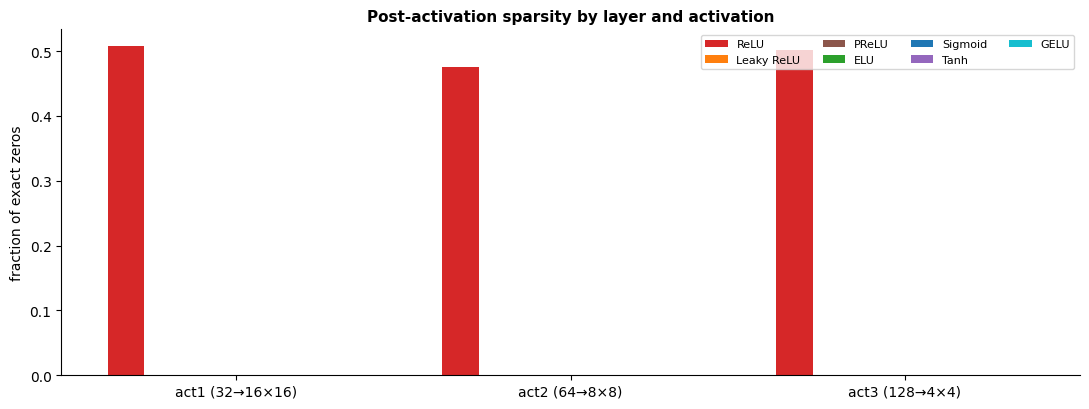

,act1,act2,act3
ReLU,0.508,0.475,0.502
Leaky ReLU,0.000,0.000,0.000
PReLU,0.000,0.000,0.000
ELU,0.000,0.000,0.000
Sigmoid,0.000,0.000,0.000
Tanh,0.000,0.000,0.000
GELU,0.000,0.000,0.000


In [28]:
cmp_models = {}
for name in ACTS:
    net = ConvNet(name, ch=(16, 32, 64)).to(DEVICE)
    ck = torch.load(os.path.join(ART, f"cmp_{name}.pt"), map_location=DEVICE, weights_only=False)
    net.load_state_dict(ck["state"]); net.eval()
    cmp_models[name] = net

sparsity = np.zeros((len(ACTS), 3))
for i, name in enumerate(ACTS):
    net = cmp_models[name]
    handles, cap = [], {}
    for l in (1, 2, 3):
        h = dict(net.named_children())[f"act{l}"].register_forward_hook(
            lambda m, inp, out, l=l: cap.__setitem__(l, out.detach()))
        handles.append(h)
    with torch.no_grad():
        net(viz_imgs)
    for l in (1, 2, 3):
        sparsity[i, l - 1] = (cap[l].abs() < 1e-6).float().mean().item()
    for h in handles: h.remove()

x = np.arange(3); width = 0.11
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, name in enumerate(ACTS):
    ax.bar(x + (i - 3) * width, sparsity[i], width, label=NAMES[name], color=COLORS[name])
ax.set_xticks(x, ["act1 (32→16×16)", "act2 (64→8×8)", "act3 (128→4×4)"])
ax.set_ylabel("fraction of exact zeros"); ax.set_title("Post-activation sparsity by layer and activation")
ax.legend(fontsize=8, ncol=4); plt.tight_layout(); plt.show()

pd.DataFrame(sparsity, index=[NAMES[a] for a in ACTS],
             columns=["act1", "act2", "act3"]).round(3)

### 5.3 · Same image, seven activations: the feature maps compared
Final head-to-head. Below, for the **cat** image: top row per activation = block-1 maps **before** the activation (signed), bottom row = **after**. All networks trained identically, so every difference you see is attributable to the non-linearity itself.

Things to spot:
- **ReLU / Leaky ReLU / PReLU**: after-maps are masks; Leaky & PReLU keep faint ghost detail in the (formerly zeroed) regions.
- **ELU**: negatives collapse onto a dark floor ($-1$) — visually similar to a mask with a residual shadow.
- **Sigmoid / Tanh**: soft, washed-out maps — every location fires *something*, all-or-nothing contrast is gone.
- **GELU**: ReLU-like contrast with slightly softer shoulders.


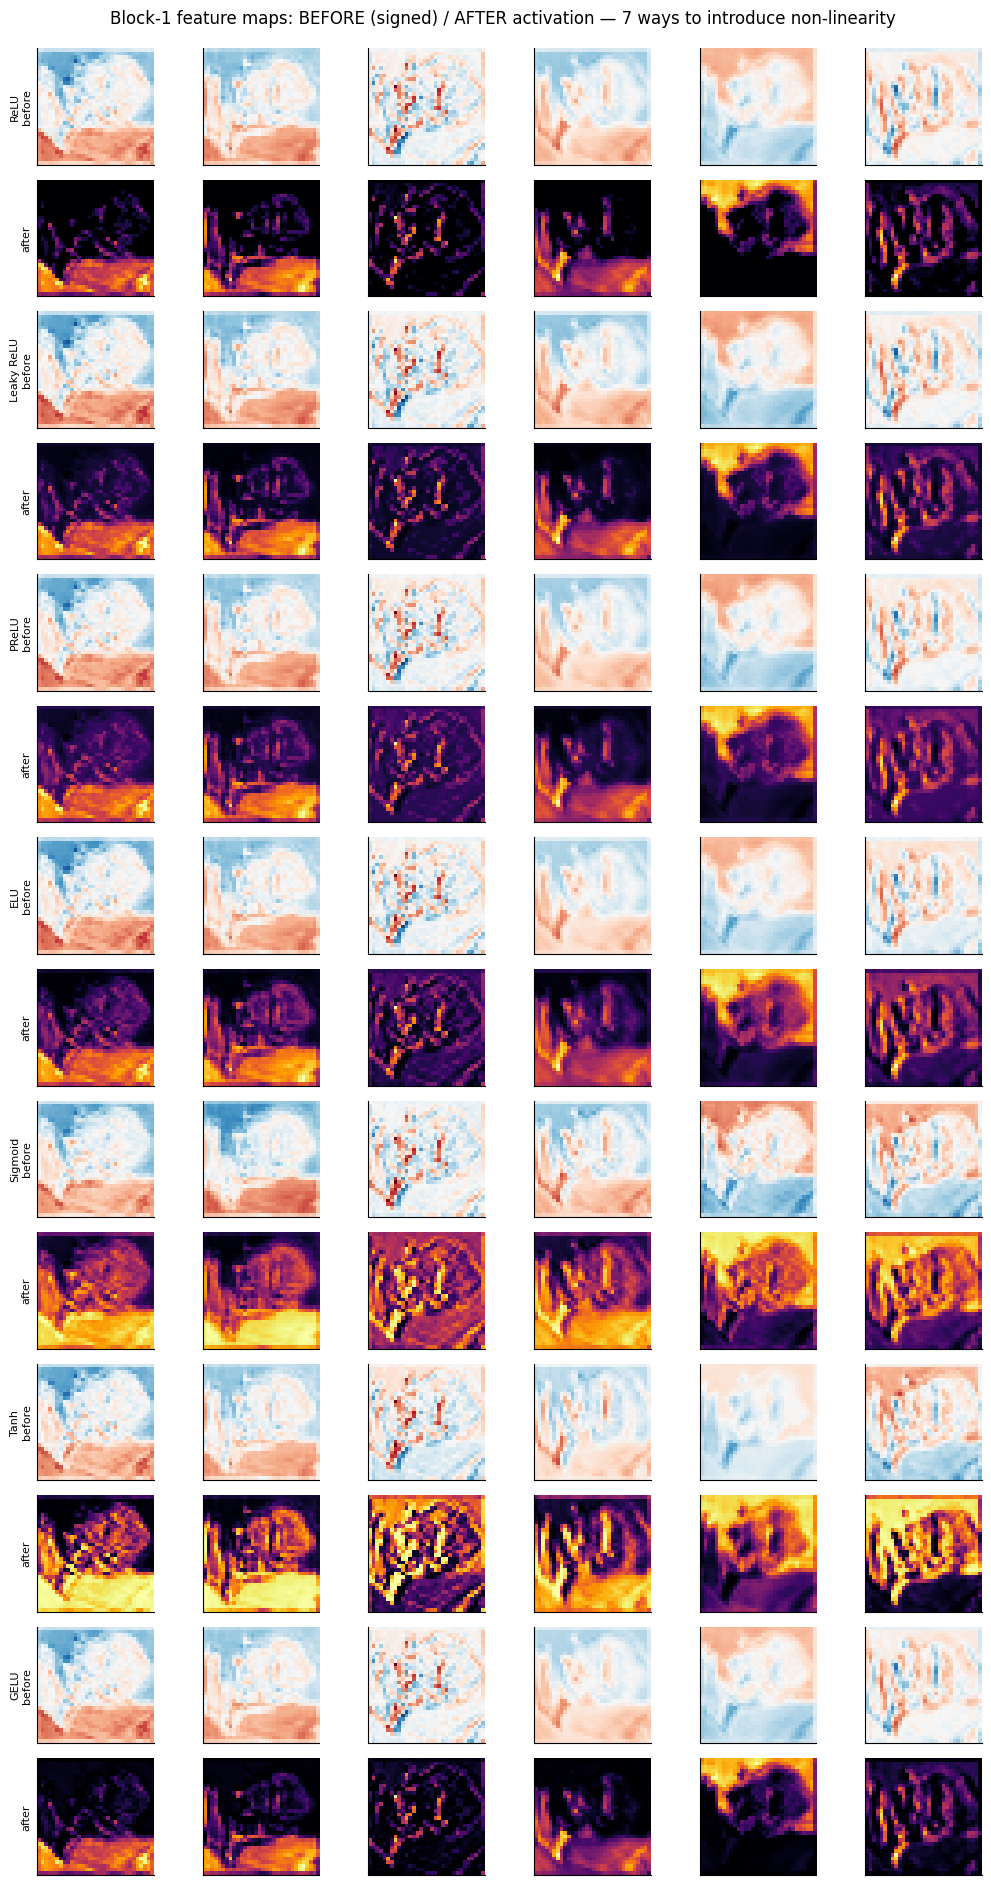

In [29]:
# capture block-1 pre/post maps from every comparison model on the cat image
cap_all = {}
for name in ACTS:
    net = cmp_models[name]
    handles, cap = [], {}
    for tag in (f"bn1", f"act1"):
        h = dict(net.named_children())[tag].register_forward_hook(
            lambda m, inp, out, tag=tag: cap.__setitem__(tag, out.detach()))
        handles.append(h)
    with torch.no_grad():
        net(viz_imgs)
    for h in handles: h.remove()
    cap_all[name] = cap

n_ch = 6
# channel ordering derived from the ReLU comparison model itself (16-channel maps)
_t = cap_all["relu"]["act1"][CAT].flatten(1)
chans = _t.var(dim=1).argsort(descending=True)[:n_ch].tolist()
fig, axes = plt.subplots(len(ACTS) * 2, n_ch, figsize=(1.75 * n_ch, 1.35 * len(ACTS) * 2))
for r, name in enumerate(ACTS):
    pre  = cap_all[name]["bn1"][CAT]
    post = cap_all[name]["act1"][CAT]
    pre_v = max(abs(pre.min()), abs(pre.max()))
    for j, c in enumerate(chans):
        axes[2*r,   j].imshow(pre[c].numpy(),  cmap="RdBu_r", vmin=-pre_v, vmax=pre_v)
        axes[2*r+1, j].imshow(post[c].numpy(), cmap="inferno")
        for ax in (axes[2*r, j], axes[2*r+1, j]): ax.set_xticks([]); ax.set_yticks([])
    axes[2*r,   0].set_ylabel(f"{NAMES[name]}\nbefore", fontsize=8)
    axes[2*r+1, 0].set_ylabel("after", fontsize=8)
fig.suptitle("Block-1 feature maps: BEFORE (signed) / AFTER activation — 7 ways to introduce non-linearity", y=0.995)
plt.tight_layout(); plt.show()

**Experimental conclusion.** Every activation turns dense signed filter responses into *shaped* evidence — but they shape it differently:
1. **Hard gate** (ReLU): maximal contrast, maximal sparsity, cheapest compute — the industry default for CNNs.
2. **Soft gate with leak** (Leaky/PReLU/ELU/GELU): keeps a thread of gradient alive through silent regions, insurance against dead units.
3. **Squashers** (Sigmoid/Tanh): compress everything into a bounded band; historically important, but saturating derivatives make deep stacks slow to train — as the loss curves showed.

In a deep vision network these per-layer "shapings" compose into the bent decision landscapes of Part 1.4 — and finally into the class probabilities we examine next.


---
# Part 6 · Visualizing decisions: *where* does the model look?
So far we inspected the *ingredients* (filters, feature maps). Now we visualize the *decision itself*: given an image, which regions pushed the network toward its answer?

**Grad-CAM** (Gradient-weighted Class Activation Mapping) answers this with one line of calculus. Let $A_k$ be the block-3 activation maps (the 128 "part detectors" of Part 4.4) and $y_c$ the logit for class $c$. The importance of map $k$ for class $c$ is the spatially-averaged gradient
$$w_k^{(c)} = \frac{1}{HW}\sum_{i,j}\frac{\partial y_c}{\partial A_k(i,j)},$$
and the class heatmap is the positive part of the weighted sum, upsampled to image size:
$$H^{(c)} = \mathrm{ReLU}\Big(\sum_k w_k^{(c)} A_k\Big).$$
Interpretation in the language of this notebook: $w_k$ asks *"how much would the cat score change if this part-detector fired a little more?"*; the heatmap then paints where the relevant part-detectors fire. Note the ReLU inside the formula — even decision *explanations* rely on the activation function to keep only positive evidence.


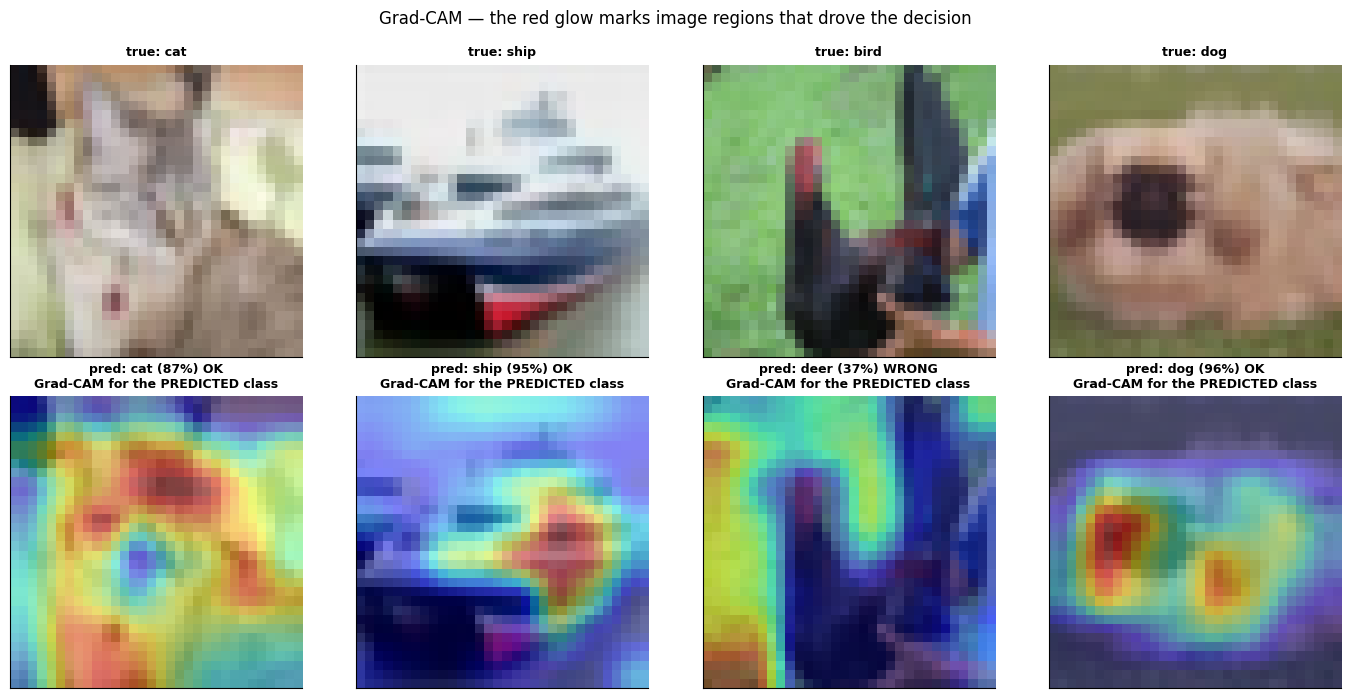

In [30]:
model.eval()
cam_acts, cam_grads = {}, {}
h1 = dict(model.named_children())["act3"].register_forward_hook(
    lambda m, i, o: cam_acts.__setitem__("a", o.detach()))
def _record_grad(m, i, o):
    # IMPORTANT: return None — a forward hook that returns a value replaces the module output!
    o.register_hook(lambda g: cam_grads.__setitem__("g", g.detach()))
h2 = dict(model.named_children())["act3"].register_forward_hook(_record_grad)

def gradcam(x, class_idx=None):
    logits = model(x.unsqueeze(0))                  # hooks record acts & grads
    if class_idx is None:
        class_idx = int(logits.argmax(1))
    model.zero_grad()
    logits[0, class_idx].backward()
    A = cam_acts["a"][0]                            # (128, 4, 4)
    G = cam_grads["g"][0]                           # (128, 4, 4)
    w = G.mean(dim=(1, 2))                          # (128,)
    cam = F.relu((w[:, None, None] * A).sum(0))     # (4, 4), ReLU keeps positive evidence
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_up = F.interpolate(cam[None, None], size=(32, 32), mode="bilinear",
                           align_corners=False)[0, 0].numpy()
    return cam_up, class_idx, logits.softmax(1)[0].detach().numpy()

# pick 4 test images: 2 confident & correct, 1 borderline correct, 1 wrong
targets = [3, 8, 2, 5]           # cat, ship, bird, dog
ids = [find_test_image(t, off) for t, off in zip(targets, [1, 0, 0, 3])]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, i in enumerate(ids):
    x, y = test_set[i]
    heatmap, pred, probs = gradcam(x)
    ok = "OK" if pred == y else "WRONG"
    axes[0, j].imshow(unnormalize(x)); axes[0, j].set_title(f"true: {CLASSES[y]}", fontsize=9)
    axes[1, j].imshow(unnormalize(x))
    axes[1, j].imshow(heatmap, cmap="jet", alpha=0.45)
    axes[1, j].set_title(f"pred: {CLASSES[pred]} ({probs[pred]:.0%}) {ok}\nGrad-CAM for the PREDICTED class", fontsize=9)
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Grad-CAM — the red glow marks image regions that drove the decision", y=0.99)
plt.tight_layout(); plt.show()
h1.remove(); h2.remove()

Read the heatmaps: for a **cat** the glow concentrates on the face/ears; for a **ship** on the hull plus the white wake; for a **bird** on the body against the sky. On the wrong prediction you can often *see the mistake* — e.g. the model looked at deer legs and interpreted the pose as a horse, or fired on dog-like fur texture.

### 6.1 · The decision read-out: logits → softmax → probability
The head collects the (ReLU-masked, non-negative) evidence into 10 logits; the final activation — **softmax** — converts them into a probability distribution. Below, the full probability bar for each image above. Watch how the softmax *amplifies* logit differences (it is exponential) and how borderline images produce flat, uncertain distributions while confident ones produce a near-one-hot spike.


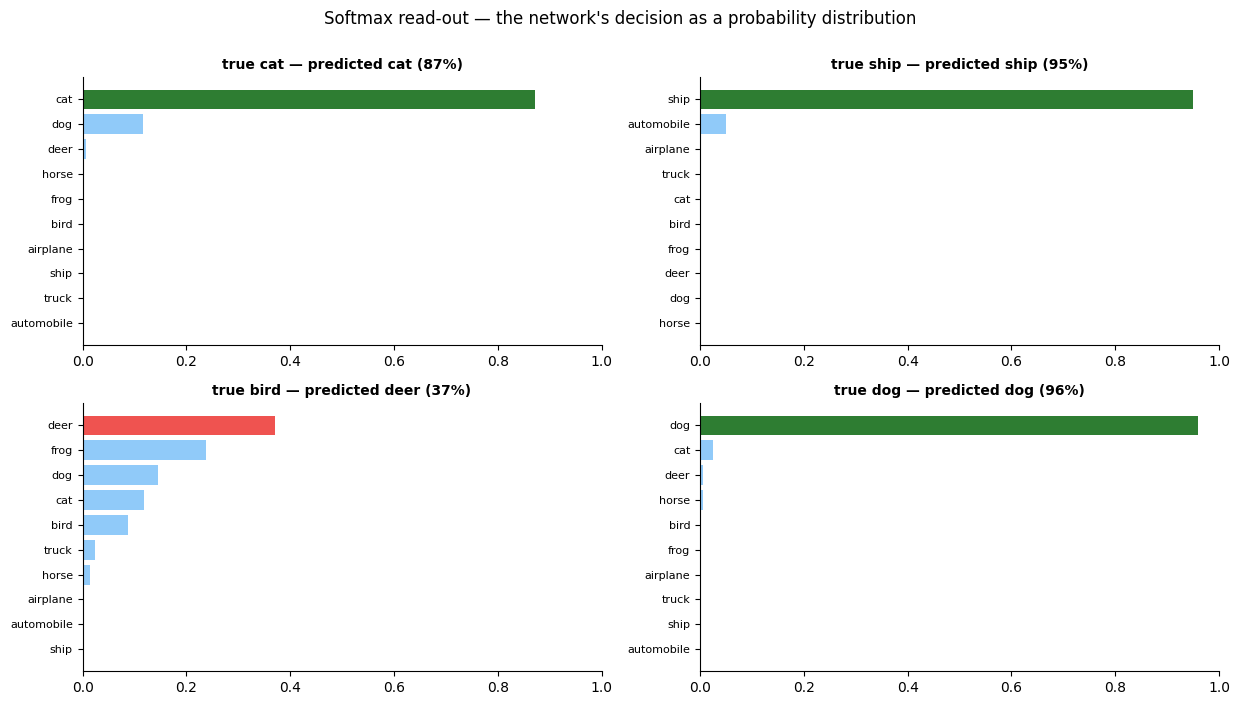

Least-confident images: mean confidence 0.28; accuracy on them: 26.0%
Most-confident images: mean confidence 1.00 vs accuracy on 200 most confident: 100.0%


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7))
for ax, i in zip(axes.ravel(), ids):
    x, y = test_set[i]
    with torch.no_grad():
        logits = model(x.unsqueeze(0))[0]
        probs = logits.softmax(0).numpy()
    o = np.argsort(probs)
    ax.barh(range(10), probs[o], color="#90caf9")
    ax.set_yticks(range(10), [CLASSES[k] for k in o], fontsize=8)
    top = o[-1]
    ax.barh(9, probs[top], color="#ef5350" if top != y else "#2e7d32")
    ax.set_title(f"true {CLASSES[y]} — predicted {CLASSES[top]} ({probs[top]:.0%})", fontsize=10)
    ax.set_xlim(0, 1)
plt.suptitle("Softmax read-out — the network's decision as a probability distribution", y=1.0)
plt.tight_layout(); plt.show()

# borderline cases: images where the model is least sure
uncertain = []
model.eval()
with torch.no_grad():
    for xb, yb in DataLoader(test_set, batch_size=512):
        p = model(xb).softmax(1)
        conf = p.max(1).values
        uncertain.append(conf)
conf_all = torch.cat(uncertain).numpy()
amb = np.argsort(conf_all)[:200]
print(f"Least-confident images: mean confidence {conf_all[amb].mean():.2f}; "
      f"accuracy on them: {(all_pred[amb] == all_true[amb]).mean():.1%}")
print(f"Most-confident images: mean confidence {conf_all.max():.2f} vs "
      f"accuracy on 200 most confident: {(all_pred[np.argsort(-conf_all)[:200]] == all_true[np.argsort(-conf_all)[:200]]).mean():.1%}")

---
# Part 7 · The decision space in 2-D and 3-D
Parts 1–6 observed the network from the *inside*. Now we look from the *outside*: as a machine that maps every point of (a simplified version of) the input space to class probabilities, sculpting a **probability landscape**.

First, a **deep** MLP (3 hidden layers of 128 ReLU units) on the 3-class spiral — the "many linear transformations + non-linear activations" recipe at work. Then we render the learned probabilities as 3-D surfaces: one hill per class, height = probability. Rotate the interactive figure: where two hills intersect along a ridge, that ridge is the decision boundary; the hilltops are confident predictions; the valleys belong to other classes.


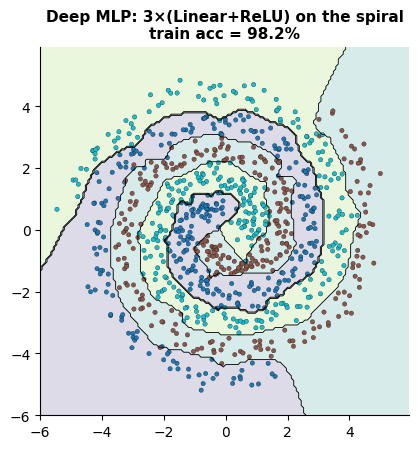

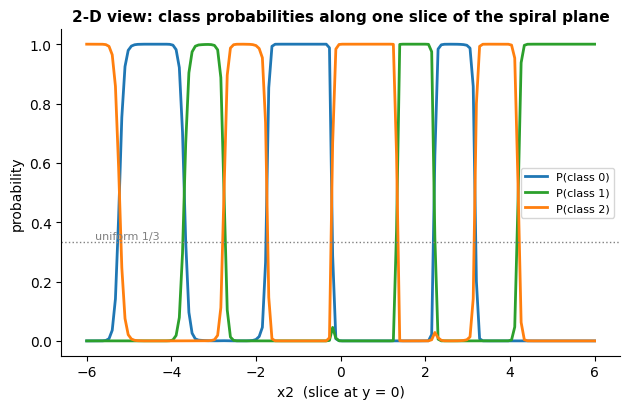

In [32]:
set_seed(SEED)
COLORS_PLT = ["#1f77b4", "#2ca02c", "#ff7f0e"]          # per-class line colours
COLORS_PLT_CMAP = ["Blues", "Greens", "Oranges"]        # per-class 3-D colormaps
deep_mlp = nn.Sequential(
    nn.Linear(2, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 3),
)
deep_mlp = train_torch_clf(deep_mlp, Xs, ys, epochs=2000, lr=3e-3)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
torch_boundary(ax, deep_mlp, Xs, ys, "Deep MLP: 3×(Linear+ReLU) on the spiral")
plt.tight_layout(); plt.show()

# ---- 2-D probability view: P(class) along a slice of the plane ---------------
xx, yy, P = proba_surface(torch_proba_func(deep_mlp), lim=6.0, n=160)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for c in range(3):
    ax.plot(np.linspace(-6, 6, 160), P[80, :, c], color=COLORS_PLT[c], lw=2, label=f"P(class {c})")
ax.axhline(1/3, color="gray", ls=":", lw=1); ax.text(-5.8, 0.345, "uniform 1/3", fontsize=8, color="gray")
ax.set_xlabel("x2  (slice at y = 0)"); ax.set_ylabel("probability")
ax.set_title("2-D view: class probabilities along one slice of the spiral plane")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

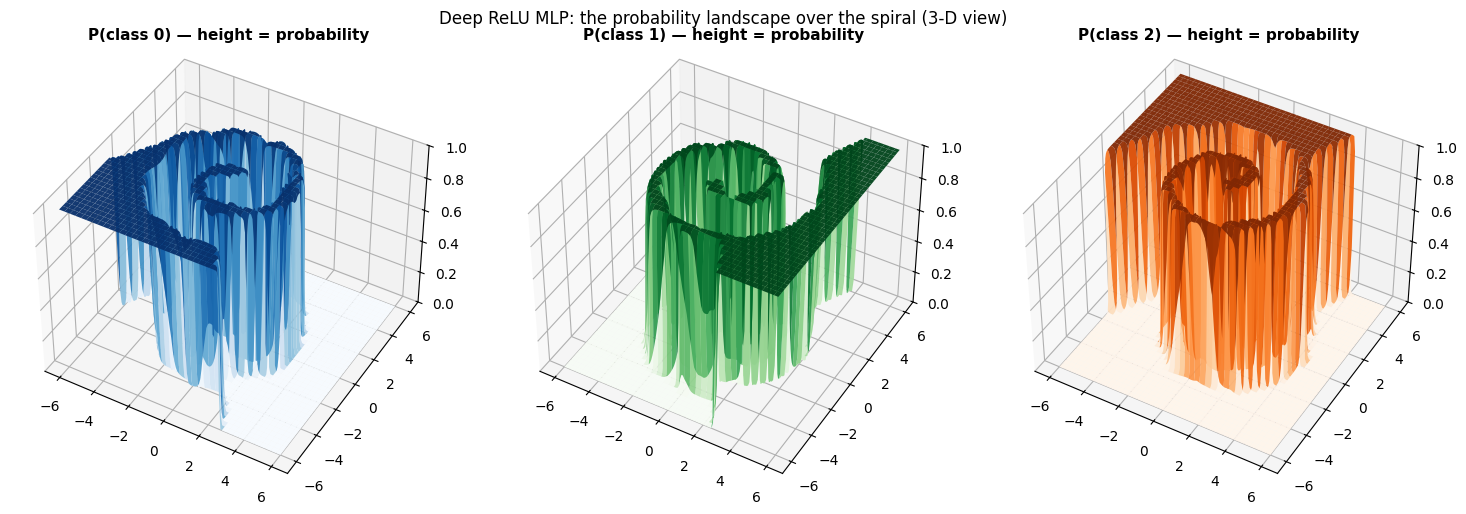

In [33]:
# ---- 3-D probability landscape: static Matplotlib + interactive Plotly -------
fig = plt.figure(figsize=(15, 5))
for c in range(3):
    ax = fig.add_subplot(1, 3, c + 1, projection="3d")
    ax.plot_surface(xx, yy, P[:, :, c], cmap=COLORS_PLT_CMAP[c], linewidth=0, antialiased=True, alpha=0.95)
    ax.set_zlim(0, 1); ax.view_init(elev=42, azim=-60)
    ax.set_title(f"P(class {c}) — height = probability")
fig.suptitle("Deep ReLU MLP: the probability landscape over the spiral (3-D view)")
plt.tight_layout(); plt.show()

if HAS_PLOTLY:
    xs1d = np.linspace(-6, 6, P.shape[0])
    fig = go.Figure()
    for c in range(3):
        fig.add_trace(go.Surface(x=xs1d, y=xs1d, z=P[:, :, c], name=f"P(class {c})",
                                 colorscale=["Blues", "Greens", "Oranges"][c],
                                 opacity=0.8, showscale=False))
    fig.update_layout(title="Rotate me: probability hills of the deep MLP (intersection ridges = decision boundaries)",
                      scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="probability",
                                 zaxis=dict(range=[0, 1])), height=600, width=800)
    fig.show()

### 7.1 · The same view for the real CNN (via PCA)
The CNN's input space is 3,072-dimensional — we cannot plot it directly. But we can take the network's **penultimate features** (the 256-dim `act4` vector that the head turns into logits) for 2,000 test images and compress them to 2-D with PCA. Each dot below is one test image, coloured by its true class.

The left panel shows the same images described by **raw pixels** — a shapeless multi-coloured blend: in pixel space the classes are hopelessly entangled (recall the spiral). The right panel shows the same images after the CNN's chain of *linear convolutions + non-linear activations*: the classes have been pulled apart into structured islands. That unfolding **is** the network's work — the activations are what allow each layer to fold, mask and recombine the previous layer's linear view.


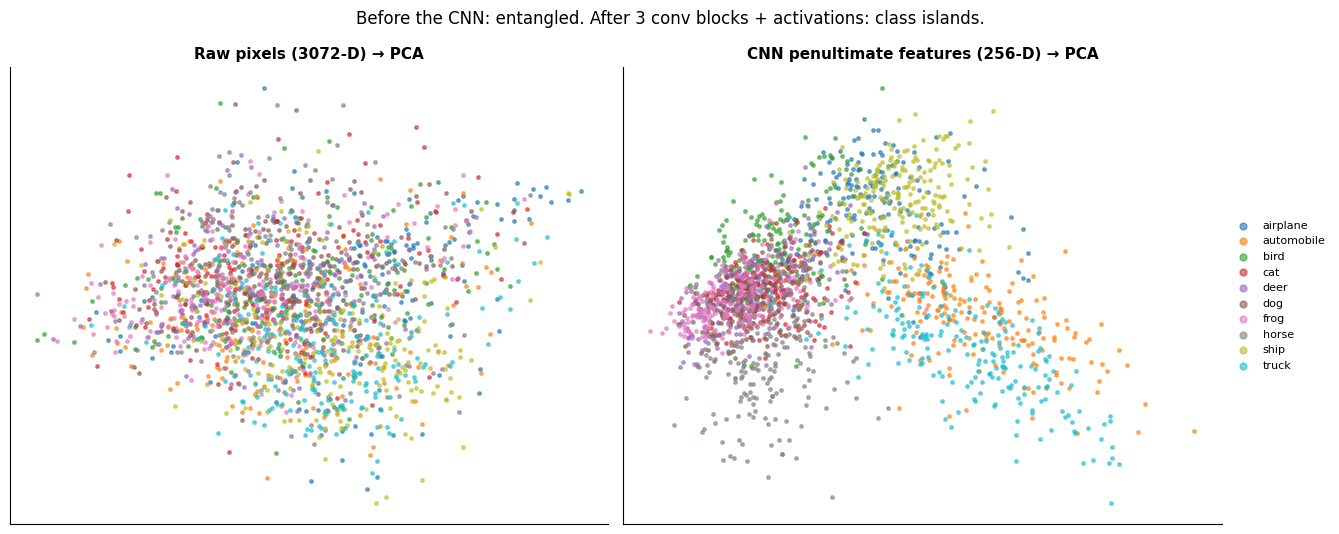

A LINEAR classifier on raw-pixel PCA:      21.8%
A LINEAR classifier on CNN-feature PCA:   46.7%
The CNN manufactured a representation that a single linear layer can now classify — that is the point of depth + non-linearity.


In [34]:
from sklearn.decomposition import PCA

feats, labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in DataLoader(Subset(test_set, range(2000)), batch_size=512):
        model(xb); feats.append(model._feat.cpu()); labels.append(yb)
feats = torch.cat(feats).numpy(); labels = torch.cat(labels).numpy()

pixels = np.stack([test_set[i][0].numpy().ravel() for i in range(2000)])
p2d_raw = PCA(n_components=2, random_state=0).fit_transform(pixels)
p2d_feat = PCA(n_components=2, random_state=0).fit_transform(feats)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
for ax, emb, title in [(axes[0], p2d_raw, "Raw pixels (3072-D) → PCA"),
                       (axes[1], p2d_feat, "CNN penultimate features (256-D) → PCA")]:
    for c in range(10):
        m = labels == c
        ax.scatter(emb[m, 0], emb[m, 1], s=6, alpha=0.6, label=CLASSES[c])
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("Before the CNN: entangled. After 3 conv blocks + activations: class islands.")
plt.tight_layout(); plt.show()

# how separable are the two embeddings? quick proxy: softmax regression on each
acc_raw  = LogisticRegression(max_iter=1000).fit(p2d_raw, labels).score(p2d_raw, labels)
acc_feat = LogisticRegression(max_iter=1000).fit(p2d_feat, labels).score(p2d_feat, labels)
print(f"A LINEAR classifier on raw-pixel PCA:      {acc_raw:.1%}")
print(f"A LINEAR classifier on CNN-feature PCA:   {acc_feat:.1%}")
print("The CNN manufactured a representation that a single linear layer can now classify — that is the point of depth + non-linearity.")

**The grand summary of Parts 1–7.**
1. A linear model draws flat decision planes; real data (spiral, CIFAR-10) is not linearly separable.
2. Stacking linear maps without activations is still one linear map — depth is wasted.
3. An activation function between layers bends the planes into curved, piecewise regions; in 3-D, flat probability sheets become hills and valleys whose ridges trace the decision boundaries.
4. In the CNN, each conv block contributes *linear pattern detectors*; the activation immediately after contributes the *masking/bending* that turns them into a hierarchy: edges → textures → parts → classes.
5. Different activations bend differently (Part 5's curves and maps) — ReLU-family gates dominate modern vision because they keep gradients alive, stay cheap, and produce sparse, interpretable evidence maps.


---
# Part 8 · Check your understanding — Questions & Answers
Try to answer before opening each solution. The questions follow the order of the notebook, so they double as a revision pass.

---

**Q1 — Remove every activation from the CIFAR-10 CNN (conv→conv→conv→FC, no `act`). What happens to (a) what the model can express, (b) its test accuracy, and why?**

<details><summary><b>Show answer</b></summary>

(a) The model collapses to a single linear/affine map of the pixels: $\text{FC}\,W_3(W_2(W_1 x)) = (W_3W_2W_1)\,x$, so the entire CNN becomes equivalent to *softmax regression* — the conv structure merely picks a particular factored weight matrix. (b) Accuracy falls from ~75–85% to roughly the ~40% linear ceiling we measured on CIFAR-10 (Part 1.2/3.2): the class regions in pixel space are far from linearly separable, and no amount of extra linear layers fixes that. This is exactly what the 4-layer linear stack on the spiral demonstrated.
</details>

---

**Q2 — In the block-1 before/after figure, the pre-activation maps contained large negative (blue) regions. What happened to them after ReLU, and what does a *zero* in a post-activation map mean?**

<details><summary><b>Show answer</b></summary>

ReLU maps every negative value to exactly 0 (red regions vanish in the after-row), while positive values pass through unchanged. A zero in the post-activation map means *"this filter's pattern is not present at this spatial location"* — it is an active claim of absence, not missing data. The negative pre-activation values were stronger than that: they encoded evidence *against* the pattern (anti-alignment), which ReLU discards rather than inverting — the next layer can re-detect pattern-presence differently, but signed evidence is not propagated. (Leaky ReLU would have kept a 0.1× echo of it — visible in Part 5.3.)
</details>

---

**Q3 — Why did Sigmoid train slowest in Part 5, in terms of the derivative plot? And why is Tanh still usually better than Sigmoid?**

<details><summary><b>Show answer</b></summary>

Backprop through 5 activated layers multiplies the local derivatives. Sigmoid's derivative is $\sigma(1-\sigma)\le 0.25$ and $\approx 0$ in the saturated tails, so the product shrinks layer by layer (vanishing gradients) and early layers receive almost no learning signal. Tanh's derivative peaks at 1.0 (4× sigmoid's max) and tanh is zero-centred, so the gradient flowing into a layer's weights has both signs and doesn't zig-zag — hence tanh > sigmoid, though both still saturate.
</details>

---

**Q4 — A ReLU neuron receives pre-activations that are negative for *every* training sample (e.g. because a previous layer's weights shifted). (a) What is its gradient? (b) What is this failure mode called? (c) Which activations from our gallery repair it, and how?**

<details><summary><b>Show answer</b></summary>

(a) Exactly 0 — ReLU's derivative is 0 on the negative side, and with zero output there is also nothing to backpropagate *through* the neuron. (b) The **dying ReLU** problem: the neuron is permanently inactive and can never update. (c) **Leaky ReLU** (fixed small negative slope, so gradient is 0.1 even when inactive), **PReLU** (same idea, slope learned per channel), **ELU** (smooth negative saturation with non-zero derivative, also pulls mean activation toward zero) and **GELU** (smooth, passes small negatives). BatchNorm also protects against it by re-centering pre-activations each layer.
</details>

---

**Q5 — In the 3-D probability landscape (Part 7), what does it mean geometrically when the three hills are (a) tilted planes, (b) sharp hills with ridge lines? Where exactly is the decision boundary?**

<details><summary><b>Show answer</b></summary>

(a) Planes = a *linear* model: probability changes at a constant rate in one direction; three planes can only carve the space with straight lines. (b) Hills = a non-linear network: probability rises in curved, localised bumps over each class region. The decision boundary is the **ridge where the two tallest hills have equal height** — in 2-D it projects to the curved boundary; in 3-D you see it as the valley/intersection line between neighbouring hills. Points far from any data fall in low, flat terrain — low confidence, because softmax only amplifies logit differences; where logits are all similar, the surface sits near $1/3$.
</details>

---

**Q6 — Why do the feature maps of block 3 look like "object parts" while block-1 maps look like edges? Nobody told layer 3 what a cat face is.**

<details><summary><b>Show answer</b></summary>

Composition + receptive field. Block-2 filters scan the *activated outputs* of block 1, so the patterns they can detect are combinations of edges (corners, textures); block 3 combines those into edge-texture constellations that align with object parts. Meanwhile pooling shrinks resolution (32→16→8→4) so each block-3 cell integrates over ~28–32 px — most of the image. Gradient descent *discovers* this hierarchy because part-like detectors are the cheapest way to reduce classification error on many images at once. The activation is essential at every level: without it, each block's "combination" would still be one big linear filter and no hierarchy of patterns could form.
</details>

---

**Q7 — Sparsity: after ReLU roughly half of all values are exactly zero (measured in Part 5.2). Give two benefits and one danger of this sparsity for a deep CNN.**

<details><summary><b>Show answer</b></summary>

Benefits: (1) *Efficiency* — zeros cost nothing to store/compute in optimized kernels and can be skipped; (2) *Disentangling/selectivity* — each image activates a small, image-dependent subset of detectors, which reduces interference between features and acts like implicit regularization; it also makes maps interpretable as masks. Danger: (1) if too many neurons die (dying ReLU), capacity is silently wasted and gradients shrink — mitigated by Leaky/ELU/GELU, BatchNorm, or lower learning rates. (Also note: sparsity means *no signed negative evidence* flows forward — the network must encode "absence" as zero, not as a negative number.)
</details>

---

**Q8 — Grad-CAM (Part 6) multiplies each block-3 map $A_k$ by an averaged gradient $w_k$, sums, and applies ReLU. Why is ReLU applied *inside the explanation*, and why do the heatmaps highlight different regions for "cat" vs. "ship" on the same image?**

<details><summary><b>Show answer</b></summary>

The weighted sum $\sum_k w_k A_k$ still contains negative values (maps with $w_k<0$ *speak against* the class). ReLU keeps only locations with net *positive* evidence — the regions that actively supported the decision. For a different class the weights $w_k^{(c)}$ are different, so the same set of maps is re-weighted: "ship" highlights hull/wake detectors, "cat" highlights fur/face detectors. One shared feature hierarchy, many class-specific read-outs — this is precisely why the CNN can share conv layers across 10 classes.
</details>

---

**Q9 — BatchNorm is placed *before* the activation. Why is this ordering kind to (a) ReLU, (b) Sigmoid?**

<details><summary><b>Show answer</b></summary>

(a) BN standardizes each channel to roughly zero mean / unit variance, then the learned $\gamma,\beta$ rescale it; for ReLU this keeps ~half of the pre-activations positive, so the neuron is neither dead (all-negative input) nor saturated at full-on, and gradients flow to about half the units. (b) For Sigmoid, keeping pre-activations near 0 matters even more, because that's where the derivative is largest ($\sigma'(0)=0.25$); unnormalized large |x| would park the unit in the flat tails where learning stalls. Activation *after* normalization also means the "before vs. after" comparison in Part 4 isolates exactly the activation's effect.
</details>

---

**Q10 — True or false, and defend: "GELU is just a smoother ReLU, so it must always train at least as well as ReLU." Use the Part 5 evidence.**

<details><summary><b>Show answer</b></summary>

Mostly false as stated. GELU *is* a smooth, non-monotonic variant of ReLU ($x\Phi(x)$): it keeps small negatives alive, avoids exact zero gradient at the kink, and in Part 5 it trained fastest/among the best — often marginally ahead of ReLU. But "always at least as well" doesn't follow: the advantage depends on architecture, batch size, dataset and budget; on small CNNs the difference is within run-to-run noise, GELU costs more compute (erf/tanh approximations), and its non-monotonic dip can occasionally hurt calibration. The honest conclusion from our controlled experiment: *all* non-saturating activations clear the big non-linearity barrier; the fine ranking is dataset- and setup-dependent.
</details>

---

## Closing summary

| Concept | Where we saw it |
|---|---|
| Linear models draw straight boundaries; real data isn't linearly separable | Part 1.1–1.2 (blobs vs. spiral) |
| Depth without activations = still one linear map | Part 1.3 (collapsed 4-layer stack) |
| Activations bend boundaries; probability becomes a 3-D landscape | Parts 1.4 & 7 (2-D/3-D surfaces, interactive Plotly) |
| Seven activation functions and their gradient personalities | Part 2 (function/derivative gallery) |
| A real CNN trained on CIFAR-10; decisions summarized | Part 3 (curves, confusion matrix) |
| Every filter & feature map; before/after activation per block | Part 4 (filter gallery, masked maps, sparsity) |
| Controlled 7-way activation comparison | Part 5 (curves, sparsity bars, map gallery) |
| Decisions localized: Grad-CAM + softmax read-out | Part 6 |
| The CNN unfolds entangled pixels into class islands | Part 7.1 (PCA before/after) |

**Further study ideas:** swap the hero model to CIFAR-100 and re-run Part 5 (saturating functions fall behind much faster); visualize *pooling* the same way we visualized activation; add attention (GELU's natural habitat) and compare; try `Kaiming` vs `Xavier` init with Sigmoid to see initialization interact with saturation; scale up epochs/augmentation on a GPU and re-measure the Part-5 ranking.
